# DAY1 배터리 수명 EDA

Batch1·Batch2·Batch3의 수명 분포, 열화 곡선, 초기 ΔQ(V), 충전 조건과 특징 상관관계를 분석한다.

이 노트북은 Batch1 단독 탐색에서 세 배치 비교로 확장한 실행 기록이다. 핵심 내용은 [DAY1 보고서](../outputs/final/DAY1_REPORT.md), 실제 모델 결과는 [DAY2 보고서](../outputs/day2/DAY2_REPORT.md)에 정리했다. 초기 탐색은 수명값이 있는 46/39/44셀 기준이며, DAY2의 Batch1 모델링 36셀과 구분한다. 실행 환경은 `requirements.txt`를 사용한다.

In [2]:
import numpy as np
import pandas as pd
import mat73                      # MATLAB v7.3 (HDF5) 형식 로드용
import scipy.io as sio            # MATLAB v7.2 이하 형식 로드용 (fallback)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from importlib.util import find_spec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [3]:
# 프로젝트 루트 또는 notebooks/에서 실행
from pathlib import Path

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == 'notebooks':
    PROJECT_DIR = PROJECT_DIR.parent
DATA_DIR = PROJECT_DIR / 'data'

BATCH_FILES = {
    'batch1': '2017-05-12_batchdata_updated_struct_errorcorrect.mat',
    'batch2': '2018-02-20_batchdata_updated_struct_errorcorrect.mat',
    'batch3': '2018-04-12_batchdata_updated_struct_errorcorrect.mat',
}

print(f"데이터 경로: {DATA_DIR}")
for batch_name, filename in BATCH_FILES.items():
    path = DATA_DIR / filename
    if not path.is_file():
        raise FileNotFoundError(f"파일을 찾지 못했습니다: {path}")
    size_gib = path.stat().st_size / (1024**3)
    print(f"{batch_name}: {filename} ({size_gib:.2f} GiB)")


데이터 경로: data/
batch1: 2017-05-12_batchdata_updated_struct_errorcorrect.mat (2.82 GiB)
batch2: 2018-02-20_batchdata_updated_struct_errorcorrect.mat (1.88 GiB)
batch3: 2018-04-12_batchdata_updated_struct_errorcorrect.mat (3.01 GiB)


## Loading

- `.mat` 파일은 MATLAB 형식이며, 이 파일은 **MATLAB v7.3(HDF5)** 포맷임
- 먼저 `scipy.io.loadmat()`을 시도하고, v7.3이면 `mat73`로 fallback 함
- 파일 크기가 크므로 **Batch 1** 하나만 먼저 로드함

In [4]:
# Batch 1 로드 (가장 많이 사용되는 기본 배치)
batch1_path = os.path.join(DATA_DIR, '2017-05-12_batchdata_updated_struct_errorcorrect.mat')

def load_mat(path):
    """
    .mat 파일 로더 (버전 자동 감지)
    - MATLAB v7.3 (HDF5, 대용량) : mat73.loadmat() 사용
    - MATLAB v7.2 이하          : scipy.io.loadmat() 사용
    """
    try:
        data = mat73.loadmat(path)
        print("로드 완료 (MATLAB v7.3 / HDF5 형식)")
    except Exception:
        data = sio.loadmat(path, simplify_cells=True)
        print("로드 완료 (MATLAB v7.2 이하 형식)")
    return data

print("로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)")
mat = load_mat(batch1_path)

# 최상위 키 확인
print(f"\n최상위 키 : {list(mat.keys())}")

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)
로드 완료 (MATLAB v7.3 / HDF5 형식)

최상위 키 : ['batch', 'batch_date']


## 데이터 타입 및 구조 확인

이 데이터셋은 `batch` 키 아래 배터리 셀 배열로 구성되어 있음

In [5]:
batch = mat['batch']

# mat73은 list of dict, scipy는 structured array로 반환
# 아래 코드로 둘 다 동일하게 처리
if isinstance(batch, dict):
    # mat73: {'field': [val0, val1, ...]} 형태 → list of dict로 변환
    keys = list(batch.keys())
    n_cells = len(batch[keys[0]])
    batch = [{k: batch[k][i] for k in keys} for i in range(n_cells)]
    print("mat73 형식 → list of dict 변환 완료")

print(f"배터리 셀 수    : {len(batch)}")
print(f"타입            : {type(batch)}")
print(f"첫 번째 셀 키   : {list(batch[0].keys())}")

mat73 형식 → list of dict 변환 완료
배터리 셀 수    : 46
타입            : <class 'list'>
첫 번째 셀 키   : ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


In [6]:
# 단일 셀 구조 상세 확인
cell0 = batch[0]

print("=" * 55)
print("배터리 셀[0] 구조")
print("=" * 55)

for key, val in cell0.items():
    if isinstance(val, np.ndarray):
        print(f"  {key:25s} | ndarray  | shape={val.shape}")
    elif isinstance(val, dict):
        print(f"  {key:25s} | dict     | keys={list(val.keys())}")
    else:
        print(f"  {key:25s} | {type(val).__name__:8s} | {val}")

배터리 셀[0] 구조
  Vdlin                     | ndarray  | shape=(1000,)
  barcode                   | NoneType | None
  channel_id                | NoneType | None
  cycle_life                | ndarray  | shape=()
  cycles                    | dict     | keys=['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
  policy                    | str      | 3_6C-80PER_3_6C
  policy_readable           | str      | 3.6C(80%)-3.6C
  summary                   | dict     | keys=['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']


In [9]:
# cycles 내부 구조 확인 (핵심 시계열 데이터)
cycles_raw = cell0['cycles']

# mat73: cycles도 dict of lists 형태로 반환 → list of dict로 변환
if isinstance(cycles_raw, dict):
    keys = list(cycles_raw.keys())
    n_cycles = len(cycles_raw[keys[0]])
    cycles = [{k: cycles_raw[k][i] for k in keys} for i in range(n_cycles)]
    print(f"mat73 형식 → list of dict 변환 완료")
else:
    cycles = cycles_raw

print(f"총 사이클 수 : {len(cycles)}")
print(f"\n사이클[0] 내 변수 목록 :")
for key, val in cycles[0].items():
    if isinstance(val, np.ndarray):
        print(f"  {key:15s} | ndarray | shape={val.shape} | dtype={val.dtype}")
    else:
        print(f"  {key:15s} | {type(val).__name__:8s} | {val}")

mat73 형식 → list of dict 변환 완료
총 사이클 수 : 1189

사이클[0] 내 변수 목록 :
  I               | NoneType | None
  Qc              | NoneType | None
  Qd              | NoneType | None
  Qdlin           | NoneType | None
  T               | NoneType | None
  Tdlin           | NoneType | None
  V               | NoneType | None
  discharge_dQdV  | NoneType | None
  t               | NoneType | None


In [10]:
for key, val in cycles[1].items():
    print(key, type(val).__name__, getattr(val, "shape", None))

I ndarray (1087,)
Qc ndarray (1087,)
Qd ndarray (1087,)
Qdlin ndarray (1000,)
T ndarray (1087,)
Tdlin ndarray (1000,)
V ndarray (1087,)
discharge_dQdV ndarray (1000,)
t ndarray (1087,)


## Summary 데이터 추출

각 배터리의 `summary` 필드에서 사이클별 요약 지표를 DataFrame으로 변환

In [11]:
def to_list_of_dicts(d):
    """mat73의 dict-of-lists 구조를 list-of-dicts로 변환"""
    if isinstance(d, dict):
        keys = list(d.keys())
        n = len(d[keys[0]])
        return [{k: d[k][i] for k in keys} for i in range(n)]
    return d  # 이미 list 형태면 그대로 반환

def extract_summary(batch):
    """모든 배터리 셀의 summary 데이터를 DataFrame으로 변환"""
    records = []
    for i, cell in enumerate(batch):
        summary = cell['summary']
        # mat73은 summary도 dict-of-lists → 각 필드를 직접 접근
        if isinstance(summary, dict):
            qd   = np.array(summary['QDischarge'])
            qc   = np.array(summary['QCharge'])
            ir   = np.array(summary['IR'])
            tmax = np.array(summary['Tmax'])
            tavg = np.array(summary['Tavg'])
            tmin = np.array(summary['Tmin'])
            ct   = np.array(summary['chargetime'])
        else:
            qd   = summary['QDischarge']
            qc   = summary['QCharge']
            ir   = summary['IR']
            tmax = summary['Tmax']
            tavg = summary['Tavg']
            tmin = summary['Tmin']
            ct   = summary['chargetime']

        cycle_life = int(cell['cycle_life'])
        policy     = str(cell.get('policy_readable') or cell.get('policy') or 'unknown')
        n          = len(qd)

        for c in range(n):
            records.append({
                'cell_id'         : i,
                'cycle'           : c + 1,
                'cycle_life'      : cycle_life,
                'charging_policy' : policy,
                'QD'              : qd[c],
                'QC'              : qc[c],
                'IR'              : ir[c],
                'Tmax'            : tmax[c],
                'Tavg'            : tavg[c],
                'Tmin'            : tmin[c],
                'chargetime'      : ct[c],
            })
    return pd.DataFrame(records)

In [12]:
df = extract_summary(batch)

print(f"DataFrame shape : {df.shape}")
df.head()

DataFrame shape : (38811, 11)


,cell_id,cycle,cycle_life,charging_policy,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
0,0,1,1190,3.6C(80%)-3.6C,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,2,1190,3.6C(80%)-3.6C,1.070689,1.071042,0.016742,35.652016,31.875011,29.566130,13.341250
2,0,3,1190,3.6C(80%)-3.6C,1.071900,1.071674,0.016724,35.692978,31.931490,29.604385,13.425777
3,0,4,1190,3.6C(80%)-3.6C,1.072510,1.072304,0.016681,35.680588,31.932603,29.744202,13.425167
4,0,5,1190,3.6C(80%)-3.6C,1.073174,1.072970,0.016662,35.728691,31.959322,29.644709,13.341442


In [13]:
# 기본 통계
df.describe().round(3)

,cell_id,cycle,cycle_life,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
count,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000
mean,20.771,442.121,884.241,1.045,1.045,0.017,37.322,33.404,30.589,11.510
std,13.469,276.876,186.940,0.059,0.061,0.001,2.760,1.964,1.575,4.518
min,0.000,1.000,534.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,9.000,211.000,731.000,1.036,1.036,0.017,35.961,32.438,29.938,10.653
50%,21.000,422.000,870.000,1.063,1.062,0.017,37.599,33.471,30.390,11.208
75%,32.000,640.000,1017.000,1.076,1.076,0.017,39.107,34.472,31.200,12.092
max,45.000,1226.000,1227.000,2.884,2.966,0.022,43.419,38.414,34.851,419.873


| 변수 | 의미 | 분석 역할 |
|---|---|---|
| QD | 방전하며 꺼낸 전하량(Ah) | 용량과 변화 추세 |
| QC | 충전 시 들어간 전하량(Ah) | 충전 용량 기록 |
| charging_policy | 충전 정책 문자열 | C1·전환 SOC·C2 비교 |

① 방전 용량 QD는 대부분 약 1.0~1.1 Ah
② cycle_life 평균 884.241을 ‘배터리 46개의 평균 수명’으로 해석하면 안 됨
    - 배터리별 평균 수명은 한 배터리당 한 행만 남겨 계산
③ 확인할 값
- QD, QC, 온도, 내부저항 등에 최솟값 0이 있음 → 초기 빈 기록이나 측정 상태와 관련됐는지 확인 필요
- QD 최대 2.884, QC 최대 2.966 → 대부분의 용량보다 크게 벗어남
- chargetime 최대 419.873 → 중앙값 11.128과 차이가 큼
- 또 0은 결측값으로 집계되지 않음. 그래서 count가 모두 같아도 모든 값이 유효하다는 뜻은 아님.

In [16]:
df.drop_duplicates("cell_id")["cycle_life"].describe().round(3)

count      46.000
mean      844.717
std       184.629
min       534.000
25%       703.250
50%       858.500
75%       914.250
max      1227.000
Name: cycle_life, dtype: float64

In [14]:
print("결측치 현황 : ")
print(df.isnull().sum())

결측치 현황 : 
cell_id            0
cycle              0
cycle_life         0
charging_policy    0
QD                 0
QC                 0
IR                 0
Tmax               0
Tavg               0
Tmin               0
chargetime         0
dtype: int64


In [17]:
print(f"\n배터리 셀 수   : {df['cell_id'].nunique()}")
print(f"충전 정책 종류 : {df['charging_policy'].nunique()}")


배터리 셀 수   : 46
충전 정책 종류 : 23


In [18]:
df.drop_duplicates("cell_id")["charging_policy"].value_counts()

charging_policy
3.6C(80%)-3.6C    3
4C(80%)-4C        2
4.8C(80%)-4.8C    2
5.4C(40%)-3.6C    2
5.4C(50%)-3C      2
5.4C(50%)-3.6C    2
5.4C(60%)-3C      2
5.4C(60%)-3.6C    2
5.4C(70%)-3C      2
5.4C(80%)-5.4C    2
6C(30%)-3.6C      2
6C(40%)-3C        2
6C(40%)-3.6C      2
6C(50%)-3C        2
6C(50%)-3.6C      2
6C(60%)-3C        2
7C(30%)-3.6C      2
7C(40%)-3C        2
7C(40%)-3.6C      2
8C(15%)-3.6C      2
8C(25%)-3.6C      2
8C(35%)-3.6C      2
4.4C(80%)-4.4C    1
Name: count, dtype: int64

정책별 평균 수명을 비교할 때, 대부분 배터리 2개로 계산한 평균

## EDA(Basic)

### 1. Cycle Life 분포

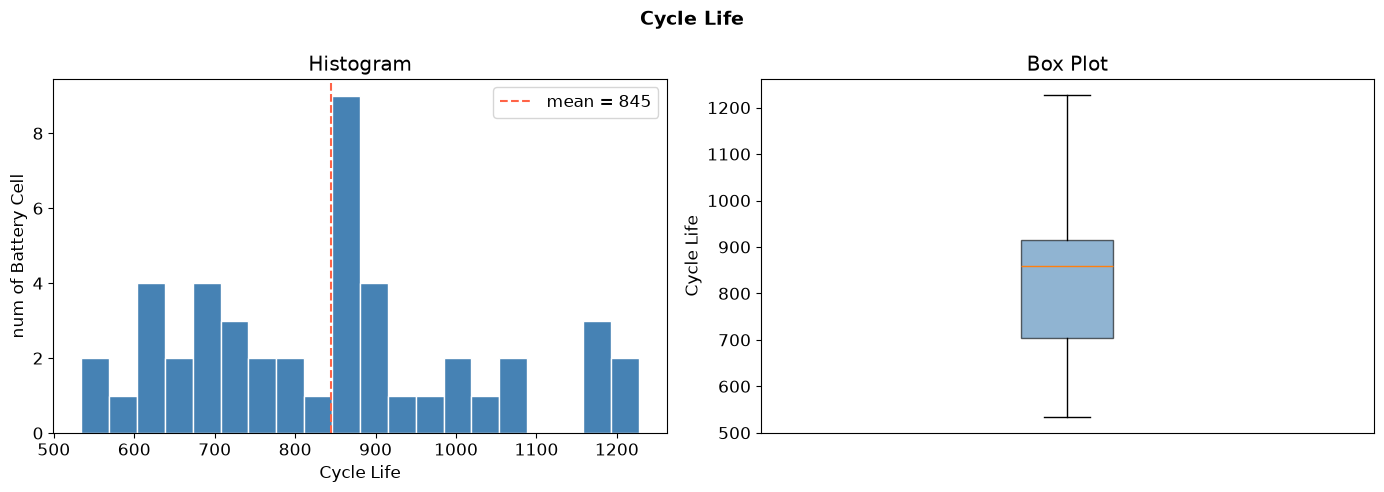

count      46.0
mean      844.7
std       184.6
min       534.0
25%       703.2
50%       858.5
75%       914.2
max      1227.0
Name: cycle_life, dtype: float64


In [19]:
cycle_life_df = df.drop_duplicates('cell_id')[['cell_id', 'cycle_life', 'charging_policy']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(cycle_life_df['cycle_life'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram')
axes[0].set_xlabel('Cycle Life')
axes[0].set_ylabel('num of Battery Cell')
axes[0].axvline(cycle_life_df['cycle_life'].mean(), color='tomato', linestyle='--',
                label=f"mean = {cycle_life_df['cycle_life'].mean():.0f}")
axes[0].legend()

# Box Plot
axes[1].boxplot(cycle_life_df['cycle_life'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Box Plot')
axes[1].set_ylabel('Cycle Life')
axes[1].set_xticks([])

plt.suptitle('Cycle Life', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(cycle_life_df['cycle_life'].describe().round(1))

Batch1의 46개 셀은 평균 수명 약 845회, 중앙값 약 859회이며, 수명은 534~1,227회에 분포한다. 셀 간 수명 차이가 있어 초기 측정값과 수명의 관계를 살펴볼 필요가 있다.

**관찰:** 제공 수명이 있는 Batch1 46셀은 평균 약 845, 중앙값 858.5사이클이며, 가운데 50%가 약 703~914사이클에 있다. 평균과 중앙값이 가깝다는 것만으로 편향이 없거나 정규분포라고 판단하지 않는다.

**해석:** 상자그림의 수염은 일반적으로 1.5 IQR 안의 관측값까지 표시된다. 수염 길이만으로 충전 조건의 효과나 장수명 예측 난이도를 결론 내릴 수 없다. 수명 구간별 예측 오차는 모델 평가에서 따로 확인한다.

### 2. 열화 곡선 - 방전 용량(QD) 감소 패턴

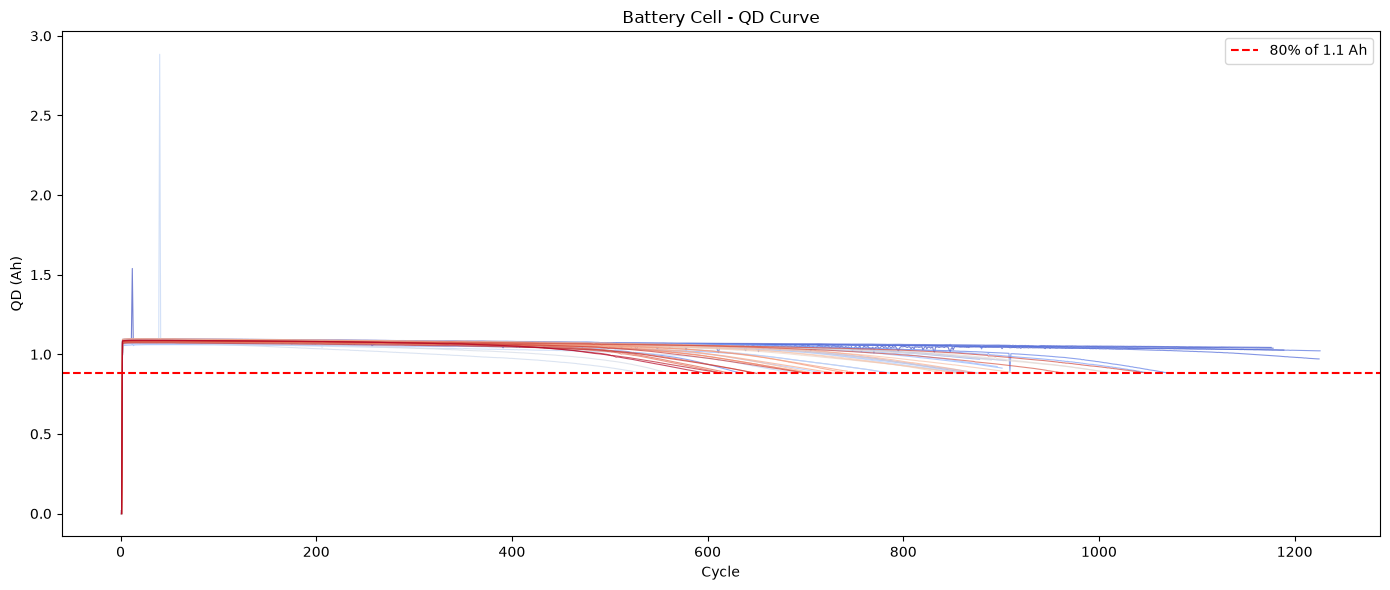

In [2]:
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df['cell_id'].unique()
colors = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df[df['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'], color=colors[i], linewidth=0.8, alpha=0.7)

nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].mean().mean()
ax.axhline(y=0.88,  # 80% of the nominal 1.1 Ah
           color='red', linestyle='--', linewidth=1.5, label='80% of 1.1 Ah')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve')
ax.legend()
plt.tight_layout()
plt.show()

[plot]
- 초기 이상값 스파이크 (cycle 0 ~ 50 구간) : 정상적인 배터리 용량을 벗어나므로, outlier filtering 고려 대상 
- 열화 패턴 : 대부분의 셀이 약 1.1Ah에서 시작해 사이클이 늘어날수록 원만하게 감소함. 논문에서 언급된 용량 열화(Capacity Fade) 곡선 형태 확인됨 
- 색상은 셀을 구분하기 위한 표시이며 수명 순서를 뜻하지 않는다. 

공칭 용량(nominal) : 1.0796 Ah
필터 범위          : 0.8637 ~ 1.2956 Ah
제거된 행 수       : 48 (0.12%)


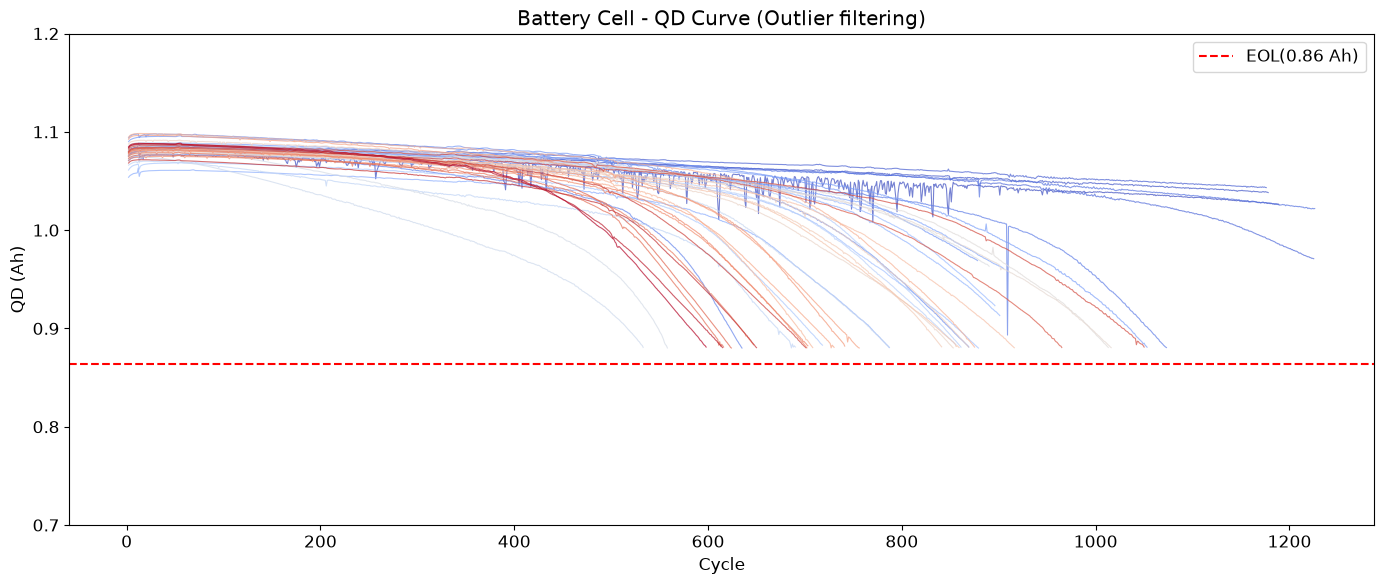

In [22]:
# 초기 탐색용 표시 범위 필터: 하한 아래의 정상 후기 열화도 빠질 수 있다.
# 전체 열화·후기 속도 분석은 아래 df_qd_valid 원자료를 사용한다.
# Outlier 필터링 후 열화 곡선 

# 1. 정상 용량 범위 정의
nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].median().median()
lower   = nominal * 0.80
upper   = nominal * 1.20

print(f"공칭 용량(nominal) : {nominal:.4f} Ah")
print(f"필터 범위          : {lower:.4f} ~ {upper:.4f} Ah")

# 2. 필터링
df_clean = df[df['QD'].between(lower, upper)].copy()
print(f"제거된 행 수       : {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.2f}%)")

# 3. 시각화
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df_clean['cell_id'].unique()
colors   = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df_clean[df_clean['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'],
            color=colors[i], linewidth=0.8, alpha=0.7)

ax.axhline(y=nominal * 0.8, color='red', linestyle='--',
           linewidth=1.5, label=f'EOL({nominal*0.8:.2f} Ah)')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve (Outlier filtering)')
ax.set_ylim(0.7, 1.2)
ax.legend()
plt.tight_layout()
plt.show()

**관찰:** 초기 QD 곡선은 약 1.06~1.10 Ah 부근에서 많이 겹치지만 이후 감소 추세는 달라진다. 일부 기록은 용량이 0.88 Ah에 도달하기 전에 끝나므로 곡선 길이를 최종 수명으로 단정하지 않는다.

**모델 연결:** 총용량만으로 보이지 않는 변화가 있는지 ΔQ(V)를 확인한다. 초기 상태 차이가 전혀 없거나 초기 QD가 무용하다는 뜻은 아니다.

### 3. 내부 저항(IR) 변화 - 열화 지표

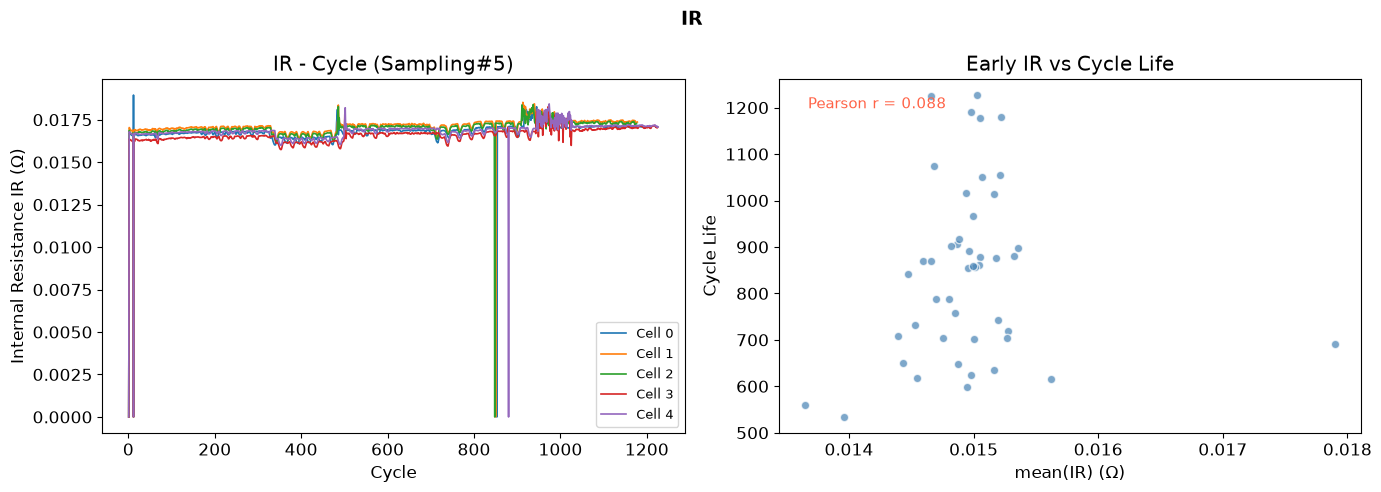

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 사이클에 따른 IR 변화 (샘플 5개)
sample_cells = cell_ids[:5]
for cid in sample_cells:
    sub = df[df['cell_id'] == cid]
    axes[0].plot(sub['cycle'], sub['IR'], label=f'Cell {cid}', linewidth=1.2)

axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Internal Resistance IR (Ω)')
axes[0].set_title('IR - Cycle (Sampling#5)')
axes[0].legend(fontsize=9)

# cycle_life vs 초기 IR 상관관계
early_ir = df[df['cycle'] <= 10].groupby('cell_id')['IR'].mean().reset_index()
early_ir.columns = ['cell_id', 'early_IR']
merged = cycle_life_df.merge(early_ir, on='cell_id')

axes[1].scatter(merged['early_IR'], merged['cycle_life'],
                alpha=0.7, color='steelblue', edgecolors='white')
axes[1].set_xlabel('mean(IR) (Ω)')
axes[1].set_ylabel('Cycle Life')
axes[1].set_title('Early IR vs Cycle Life')

corr = merged['early_IR'].corr(merged['cycle_life'])
axes[1].text(0.05, 0.95, f'Pearson r = {corr:.3f}',
             transform=axes[1].transAxes, fontsize=11,
             verticalalignment='top', color='tomato')

plt.suptitle('IR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**관찰:** 선택한 셀의 IR 변화는 용량 변화보다 작아 보이며, 이 단계의 단순 상관은 약 0.088로 약하다. 이는 모든 비선형 관계나 다른 변수와의 조합 효과가 없다는 뜻은 아니다.

스파이크만으로 셀 교체·측정 오류·특정 전극 구조를 확인할 수 없다. 후속 분석에서는 유효 저항값으로 초기 IR 수준과 변화율을 만들고 보조 특징으로 비교한다.

### 4. 충전 정책(C-rate)과 수명의 관계

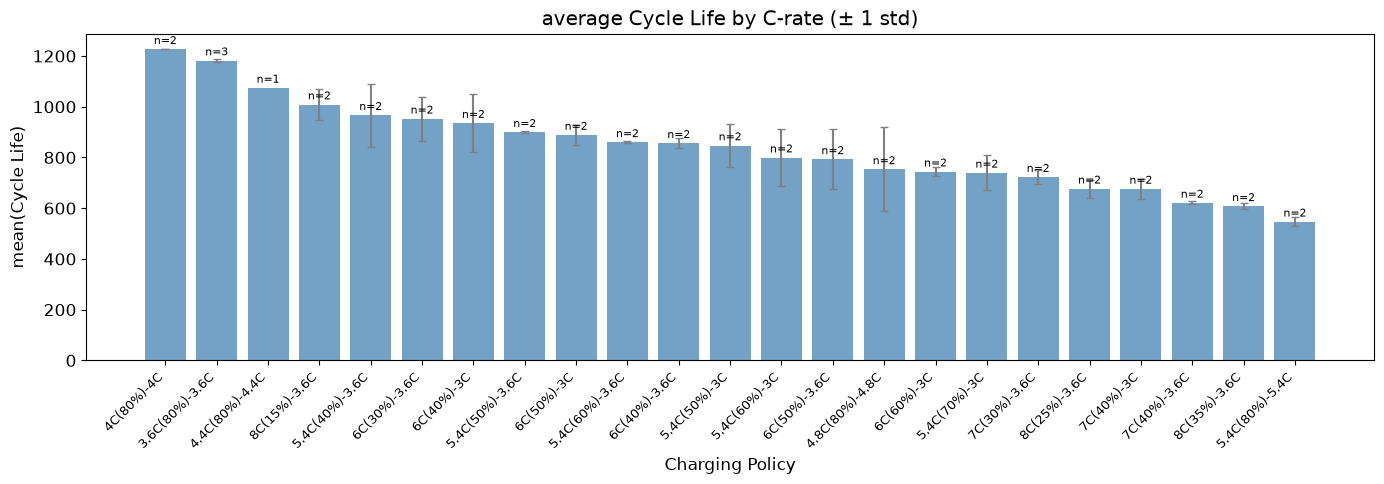

In [26]:
policy_life = cycle_life_df.groupby('charging_policy')['cycle_life'].agg(['mean', 'std', 'count'])
policy_life = policy_life.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(policy_life))
bars = ax.bar(x, policy_life['mean'], 
               yerr=policy_life['std'],
               color='steelblue', alpha=0.75,
               error_kw=dict(ecolor='gray', capsize=3))
ax.set_xticks(x)
ax.set_xticklabels(policy_life.index, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Charging Policy')
ax.set_ylabel('mean(Cycle Life)')
ax.set_title('average Cycle Life by C-rate (± 1 std)')

for bar, (_, row) in zip(bars, policy_life.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'n={int(row["count"])}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

C-rate는 정격 용량에 대한 충·방전 전류의 상대 크기다. 예를 들어 1.1 Ah 셀의 1C는 1.1 A이다. 1C=1시간은 이상적인 일정 전류 환산이며, 실제 완충 시간은 시작 SOC와 후반 충전 절차에 따라 달라진다.

정책 문자열의 C1·전환 SOC·C2는 두 단계 전류와 전환 조건을 나타낸다. 표기만으로 전 구간의 실제 전류 파형이나 완충 시간을 재구성하지 않는다.

**관찰:** Batch1에서는 일부 높은 전류 정책의 평균 수명이 짧았고, 같은 8C라도 전환 SOC가 달라지면 평균 수명이 달랐다. 정책별 표본이 대부분 2셀이라 독립적인 효과를 분리하기 어렵다.

**모델 연결:** C1뿐 아니라 전환 SOC·C2를 함께 후보로 둔다. 배치 전체를 비교한 뒤 공통 관계인지 확인하며, 특정 손상 기전이나 충전 조건의 인과효과는 이 그래프만으로 확정하지 않는다.

**도메인 가설:** 높은 전류와 적용 SOC 구간에 따라 충전 부담이 달라질 수 있다. 이번 데이터에서는 여러 조건이 함께 바뀌므로, 이 가설을 단일 인과 규칙으로 사용하지 않는다.

### 5. 상관관계 히트맵

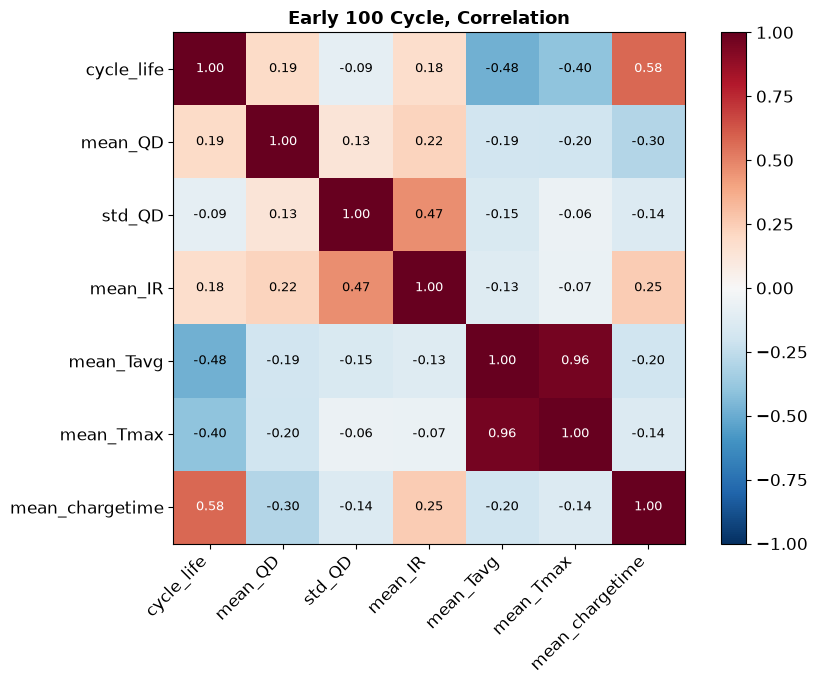


[cycle_life Corr Rank]
mean_chargetime    0.577
mean_Tavg         -0.482
mean_Tmax         -0.404
mean_QD            0.193
mean_IR            0.177
std_QD            -0.090
Name: cycle_life, dtype: float64


In [27]:
# 배터리별 초기 100 사이클 평균 집계
early = df[df['cycle'] <= 100].groupby('cell_id').agg(
    cycle_life   = ('cycle_life', 'first'),
    mean_QD      = ('QD', 'mean'),
    std_QD       = ('QD', 'std'),
    mean_IR      = ('IR', 'mean'),
    mean_Tavg    = ('Tavg', 'mean'),
    mean_Tmax    = ('Tmax', 'mean'),
    mean_chargetime = ('chargetime', 'mean'),
).reset_index(drop=True)

corr_matrix = early.corr()

import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

labels = corr_matrix.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=color)

ax.set_title('Early 100 Cycle, Correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n[cycle_life Corr Rank]")
print(corr_matrix['cycle_life'].drop('cycle_life').sort_values(key=abs, ascending=False).round(3))

**관찰:** 이 Batch1 분석에서는 충전시간과 수명이 양의 상관, 온도와 수명이 음의 상관을 보였다. Tavg·Tmax 사이 상관은 약 0.96으로 높았다.

**해석:** 발열이 수명 감소를 일으켰다는 인과관계를 확인한 것은 아니다. 다른 충전 조건이나 실험 집단도 함께 영향을 줄 수 있다. 온도 대표값 하나를 우선 사용하고, 다른 배치에서 같은 관계가 유지되는지 확인한다.

| 변수 | 수명과 상관계수 | 해석 |
|---|---:|---|
| 평균 충전 시간 | **+0.577** | 초기 충전 시간이 긴 셀일수록 수명이 긴 경향 |
| 평균 온도 | **−0.482** | 초기 평균 온도가 높은 셀일수록 수명이 짧은 경향 |
| 평균 최고 온도 | **−0.404** | 초기 최고 온도가 높은 셀일수록 수명이 짧은 경향 |
| 평균 QD / 평균 IR | +0.193 / +0.177 | 수명과 선형 관계가 약함 |
| QD 표준편차 | −0.090 | 수명과 뚜렷한 선형 관계가 보이지 않음 |

큰 충전 전류에 따른 발열·전기화학적 부담이 열화를 촉진할 수 있다

평균 온도와 평균 최고 온도의 상관이 0.96, 두 변수는 비슷한 정보를 많이 담고 있다.
지금 모델링에 가져갈 결론은 충전 시간·온도를 우선 후보로 두고, 초기 QD 변화량과 ΔQ(V)를 추가로 살펴봄

상관이 약한 변수도 다른 변수와 조합하면 도움이 될 수 있으니 바로 제외할 필요는 없음


## 세 배치로 분석 확장

수명 분포, 열화 곡선, ΔQ, 충전 조건, 특징 상관을 Batch1·2·3에서 비교한다. DAY2는 초기 100사이클을 사용한 수명 회귀로 진행한다. 세부 설계는 노트북 마지막과 DAY1 보고서에 정리한다.

## ΔQ 해석과 세 배치 비교

ΔQ(V)는 “초기 두 사이클 사이에 방전 곡선이 얼마나 바뀌었는가”
Q(V)는 방전 중 전압이 V에 도달할 때까지 꺼낸 누적 전하량
| 같은 전압 3.0 V에서 | 누적 방전량 |
|---|---:|
| 10사이클 | 0.60 Ah |
| 100사이클 | 0.57 Ah |
| 차이 ΔQ(3.0 V) | −0.03 Ah |

이 계산을 Vdlin의 1,000개 전압 지점마다 하면 1,000개 값으로 이루어진 차이 곡선이 나옴. 총 방전 용량 QD의 차이 하나보다, 방전 과정의 어느 전압 구간에서 변화가 생겼는지 더 자세히 볼 수 있음

가설: 초기 총용량이 비슷해도 방전 곡선 변화에 이후 수명과 연관된 정보가 있을 수 있다. 아래에서 실제 관계를 확인한다.


In [28]:
# 실제 사이클 번호와 cycles의 위치를 연결하기 위한 확인
summary_cycles = np.asarray(cell0["summary"]["cycle"]).reshape(-1)

print("summary의 처음 12개 사이클 번호:", summary_cycles[:12])
print("summary 기록 수:", len(summary_cycles))
print("cycles 기록 수:", len(cycles))

for i in range(3):
    q = cycles[i]["Qdlin"]
    print(f"cycles[{i}] Qdlin:", getattr(q, "shape", None))

summary의 처음 12개 사이클 번호: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12.]
summary 기록 수: 1189
cycles 기록 수: 1189
cycles[0] Qdlin: None
cycles[1] Qdlin: (1000,)
cycles[2] Qdlin: (1000,)


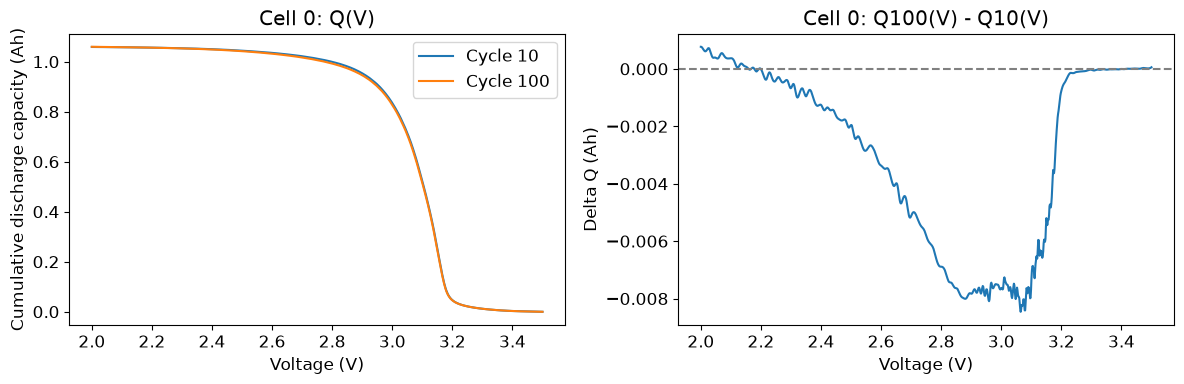

ΔQ 평균: -0.002873 Ah
ΔQ 분산: 0.00000966 Ah²


In [29]:
# summary의 실제 사이클 번호로 위치 선택
i10 = np.flatnonzero(summary_cycles == 10)[0]
i100 = np.flatnonzero(summary_cycles == 100)[0]

q10_raw = cycles[i10]["Qdlin"]
q100_raw = cycles[i100]["Qdlin"]

if q10_raw is None or q100_raw is None:
    raise ValueError("10 또는 100사이클의 Qdlin이 비어 있습니다.")

voltage = np.asarray(cell0["Vdlin"]).reshape(-1)
q10 = np.asarray(q10_raw).reshape(-1)
q100 = np.asarray(q100_raw).reshape(-1)

delta_q = q100 - q10

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(voltage, q10, label="Cycle 10")
axes[0].plot(voltage, q100, label="Cycle 100")
axes[0].set(
    xlabel="Voltage (V)",
    ylabel="Cumulative discharge capacity (Ah)",
    title="Cell 0: Q(V)"
)
axes[0].legend()

axes[1].plot(voltage, delta_q)
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].set(
    xlabel="Voltage (V)",
    ylabel="Delta Q (Ah)",
    title="Cell 0: Q100(V) - Q10(V)"
)

plt.tight_layout()
plt.show()

print(f"ΔQ 평균: {np.mean(delta_q):.6f} Ah")
print(f"ΔQ 분산: {np.var(delta_q):.8f} Ah²")

같은 전압에서 두 사이클의 누적 방전량 차이가 크게 드러난 구간을 관찰했다. 이것만으로 3 V에서 손상이 발생했다거나 특정 내부 열화 기전을 확인했다고 해석하지 않는다.

46개 셀의 ΔQ(V) 분산을 구해서 수명과 비교

계산 완료: 46개 / 전체 46개


,cell_id,cycle_life,delta_Q_mean,delta_Q_min,delta_Q_var,log10_delta_Q_var
0,0,1190.0,-0.002873,-0.008460,0.000010,-5.014861
1,1,1179.0,-0.004100,-0.011004,0.000010,-5.013960
2,2,1177.0,-0.004487,-0.017216,0.000018,-4.737000
3,3,1226.0,-0.007456,-0.018961,0.000036,-4.442613
4,4,1227.0,-0.005750,-0.013958,0.000023,-4.647744


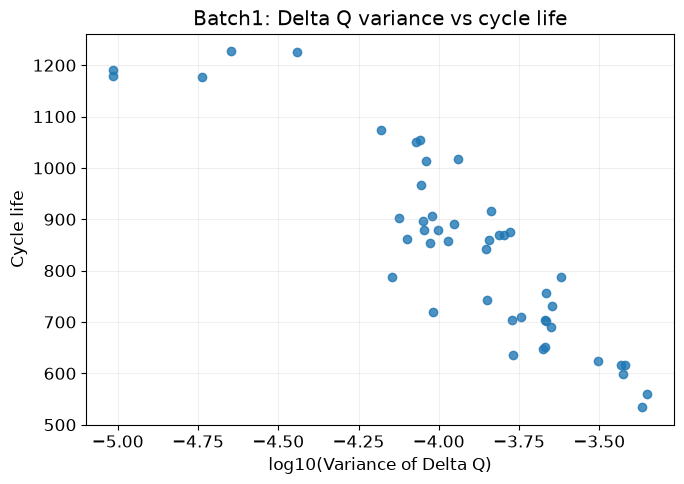

로그 분산과 수명의 Pearson 상관계수: -0.886


In [31]:
records = []
skipped = []

for cell_id, cell in enumerate(batch):
    try:
        # 실제 사이클 번호에서 10·100사이클의 위치 찾기
        cycle_numbers = np.asarray(
            cell["summary"]["cycle"]
        ).reshape(-1)

        i10 = np.flatnonzero(cycle_numbers == 10)[0]
        i100 = np.flatnonzero(cycle_numbers == 100)[0]

        # 셀별 cycles 구조에 맞춰 Qdlin 가져오기
        raw_cycles = cell["cycles"]

        if isinstance(raw_cycles, dict):
            q10_raw = raw_cycles["Qdlin"][i10]
            q100_raw = raw_cycles["Qdlin"][i100]
        else:
            q10_raw = raw_cycles[i10]["Qdlin"]
            q100_raw = raw_cycles[i100]["Qdlin"]

        if q10_raw is None or q100_raw is None:
            raise ValueError("Qdlin이 비어 있음")

        q10 = np.asarray(q10_raw, dtype=float).reshape(-1)
        q100 = np.asarray(q100_raw, dtype=float).reshape(-1)

        if q10.size == 0 or q10.shape != q100.shape:
            raise ValueError("두 곡선의 길이가 맞지 않음")

        if not (np.isfinite(q10).all() and np.isfinite(q100).all()):
            raise ValueError("곡선에 결측값 또는 무한대가 있음")

        delta_q = q100 - q10
        variance = np.var(delta_q)

        records.append({
            "cell_id": cell_id,
            "cycle_life": float(
                np.asarray(cell["cycle_life"]).item()
            ),
            "delta_Q_mean": np.mean(delta_q),
            "delta_Q_min": np.min(delta_q),
            "delta_Q_var": variance,
            "log10_delta_Q_var": (
                np.log10(variance) if variance > 0 else np.nan
            ),
        })

    except (KeyError, IndexError, TypeError, ValueError) as error:
        skipped.append((cell_id, str(error)))

df_delta = pd.DataFrame(records)

print(f"계산 완료: {len(df_delta)}개 / 전체 {len(batch)}개")
if skipped:
    print("계산하지 못한 셀:", skipped)

display(df_delta.head())

# 분산은 값의 규모 차이를 보기 쉽도록 로그로 표시
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    df_delta["log10_delta_Q_var"],
    df_delta["cycle_life"],
    alpha=0.8
)

ax.set(
    xlabel="log10(Variance of Delta Q)",
    ylabel="Cycle life",
    title="Batch1: Delta Q variance vs cycle life"
)

ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

r = df_delta["log10_delta_Q_var"].corr(df_delta["cycle_life"])
print(f"로그 분산과 수명의 Pearson 상관계수: {r:.3f}")

ΔQ(V)의 분산이 큰 셀일수록 수명이 짧은 경향
- 왼쪽 위: 분산이 작고, 수명이 긴 셀
- 오른쪽 아래: 분산이 크고, 수명이 짧은 셀
- Pearson r = −0.886: 강한 음의 선형 상관

| 초기 특징 | 상관계수 |
|---|---:|
| 평균 QD | +0.193 |
| 평균 충전 시간 | +0.577 |
| **ΔQ(V) 로그 분산** | **−0.886** |

회귀 모델의 유력한 입력 후보


평균·최솟값·로그 분산과 수명의 상관을 비교하고, 제공 수명값 기준 최단·최장 셀의 ΔQ 형태를 살펴본다.

ΔQ 특징과 수명의 Pearson 상관계수


log10_delta_Q_var   -0.886
delta_Q_min          0.882
delta_Q_mean         0.854
Name: cycle_life, dtype: float64

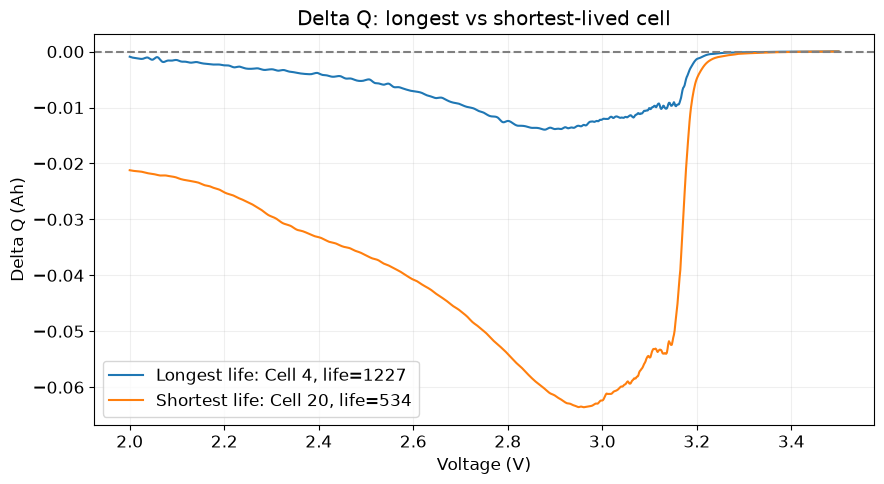

In [32]:
# 1. ΔQ 특징별 수명과의 상관 비교
features = ["delta_Q_mean", "delta_Q_min", "log10_delta_Q_var"]

correlations = (
    df_delta[["cycle_life"] + features]
    .corr()["cycle_life"]
    .drop("cycle_life")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

print("ΔQ 특징과 수명의 Pearson 상관계수")
display(correlations.round(3))


# 2. 수명이 가장 긴 셀과 가장 짧은 셀 선택
selected = [
    ("Longest life", df_delta.loc[df_delta["cycle_life"].idxmax()]),
    ("Shortest life", df_delta.loc[df_delta["cycle_life"].idxmin()]),
]

fig, ax = plt.subplots(figsize=(9, 5))

for label, row in selected:
    cid = int(row["cell_id"])
    cell = batch[cid]

    numbers = np.asarray(cell["summary"]["cycle"]).reshape(-1)
    i10 = np.flatnonzero(numbers == 10)[0]
    i100 = np.flatnonzero(numbers == 100)[0]

    raw = cell["cycles"]
    if isinstance(raw, dict):
        q10 = raw["Qdlin"][i10]
        q100 = raw["Qdlin"][i100]
    else:
        q10 = raw[i10]["Qdlin"]
        q100 = raw[i100]["Qdlin"]

    delta = (
        np.asarray(q100).reshape(-1)
        - np.asarray(q10).reshape(-1)
    )
    voltage = np.asarray(cell["Vdlin"]).reshape(-1)

    ax.plot(
        voltage, delta,
        label=f"{label}: Cell {cid}, life={row['cycle_life']:.0f}"
    )

ax.axhline(0, color="gray", linestyle="--")
ax.set(
    xlabel="Voltage (V)",
    ylabel="Delta Q (Ah)",
    title="Delta Q: longest vs shortest-lived cell"
)
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

| ΔQ 특징 | 수명과 상관계수 | 해석 |
|---|---:|---|
| 로그 분산 | **−0.886** | 전압별 변화량의 차이가 클수록 수명이 짧은 경향 |
| 최솟값 | **+0.882** | 가장 크게 감소한 지점의 값이 더 음수일수록 수명이 짧은 경향 |
| 평균 | **+0.854** | 곡선 차이가 평균적으로 더 음수일수록 수명이 짧은 경향 |

평균: 곡선이 전체적으로 얼마나 내려갔는가

최솟값: 가장 깊게 내려간 지점은 어디까지인가

분산: 전압별 변화량이 얼마나 다른가

In [33]:
features = ["delta_Q_mean", "delta_Q_min", "log10_delta_Q_var"]
display(df_delta[features].corr().round(3))

,delta_Q_mean,delta_Q_min,log10_delta_Q_var
delta_Q_mean,1.000,0.993,-0.926
delta_Q_min,0.993,1.000,-0.947
log10_delta_Q_var,-0.926,-0.947,1.000


세 특징을 같은 계열로 묶고, 논문처럼 로그 분산을 대표 후보로 선택

Batch2·3 확장해서 배치별 수명 분포를 비교

,count,mean,std,min,25%,50%,75%,max
batch,,,,,,,,
Batch1,46.0,844.7,184.6,534.0,703.2,858.5,914.2,1227.0
Batch2,39.0,565.7,222.2,392.0,439.5,472.0,508.5,1186.0
Batch3,44.0,1059.7,313.9,541.0,828.0,1005.5,1155.2,1935.0


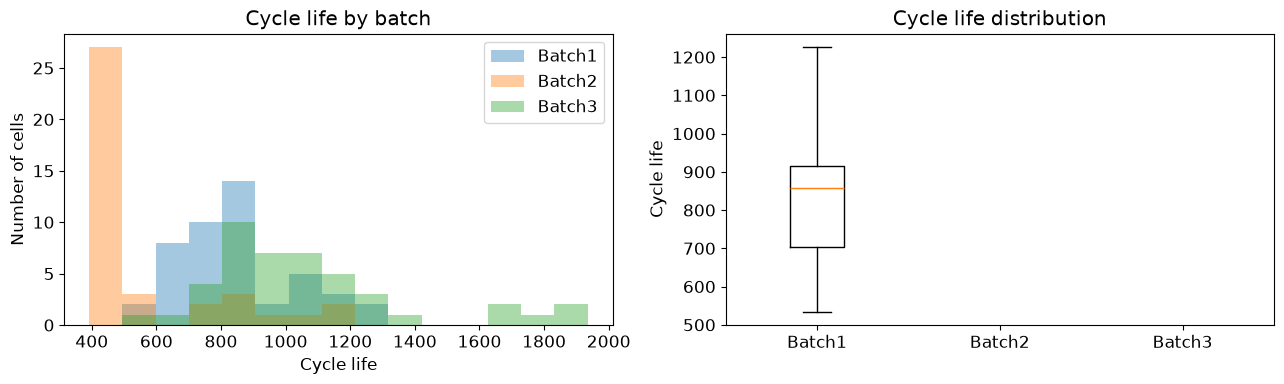

In [34]:
from pathlib import Path
import h5py

data_dir = DATA_DIR

batch_files = {
    "Batch2": "2018-02-20_batchdata_updated_struct_errorcorrect.mat",
    "Batch3": "2018-04-12_batchdata_updated_struct_errorcorrect.mat",
}

# Batch1은 이미 만든 표 사용
life_tables = [
    df.drop_duplicates("cell_id")[["cell_id", "cycle_life"]]
      .assign(batch="Batch1")
]

# Batch2·3은 cycle_life만 읽기
for batch_name, filename in batch_files.items():
    rows = []

    with h5py.File(data_dir / filename, "r") as f:
        references = f["batch"]["cycle_life"][()].reshape(-1)

        for cell_id, reference in enumerate(references):
            dataset = f[reference]

            if dataset.attrs.get("MATLAB_empty", 0):
                print(f"{batch_name} Cell {cell_id}: 수명값 없음")
                continue

            life = float(np.asarray(dataset[()]).item())

            rows.append({
                "batch": batch_name,
                "cell_id": cell_id,
                "cycle_life": life,
            })

    life_tables.append(pd.DataFrame(rows))

df_life_batches = pd.concat(life_tables, ignore_index=True)

# 배치별 수명 통계
display(
    df_life_batches.groupby("batch")["cycle_life"]
    .describe()
    .round(1)
)

# 같은 구간으로 히스토그램 비교
batch_names = ["Batch1", "Batch2", "Batch3"]
bins = np.linspace(
    df_life_batches["cycle_life"].min(),
    df_life_batches["cycle_life"].max(),
    16
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

values = []
for name in batch_names:
    life = df_life_batches.loc[
        df_life_batches["batch"] == name, "cycle_life"
    ]
    values.append(life.to_numpy())

    axes[0].hist(life, bins=bins, alpha=0.4, label=name)

axes[0].set(
    xlabel="Cycle life",
    ylabel="Number of cells",
    title="Cycle life by batch"
)
axes[0].legend()

axes[1].boxplot(values)
axes[1].set_xticks([1, 2, 3], batch_names)
axes[1].set(ylabel="Cycle life", title="Cycle life distribution")

plt.tight_layout()
plt.show()

| 배치 | 유효 수명값 수 | 중앙값 | 관찰 |
|---|---:|---:|---|
| Batch1 | 46 | 858.5회 | 중간 수명 구간 |
| Batch2 | 39 | 472회 | 짧은 수명 쪽에 집중 |
| Batch3 | 44 | 1,005.5회 | 긴 수명 쪽에 있고 범위도 넓음 |

배치별 수명 결측 수를 다음 단계에서 확인한다.

,전체_기록수,유효_수명수
batch,,
Batch1,46,46
Batch2,47,39
Batch3,46,44


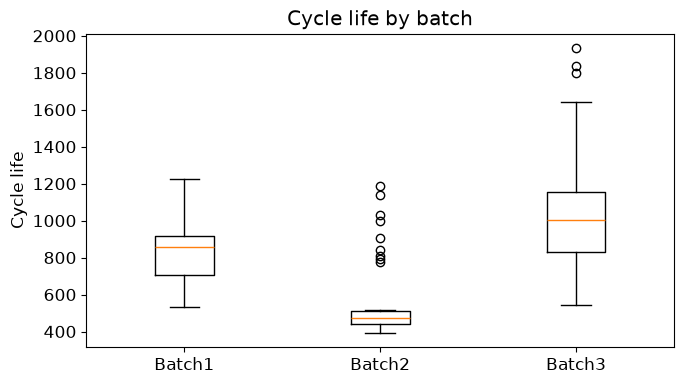

In [35]:
display(
    df_life_batches.groupby("batch")["cycle_life"]
    .agg(전체_기록수="size", 유효_수명수="count")
)

values = [
    df_life_batches.loc[
        df_life_batches["batch"] == name, "cycle_life"
    ].dropna().to_numpy()
    for name in batch_names
]

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(values)
ax.set_xticks([1, 2, 3], batch_names)
ax.set(ylabel="Cycle life", title="Cycle life by batch")
plt.tight_layout()
plt.show()

| 배치 | 전체 셀 수 | 유효 수명값 | 결측 수명값 |
|---|---:|---:|---:|
| Batch1 | 46 | 46 | 0 |
| Batch2 | 47 | 39 | 8 |
| Batch3 | 46 | 44 | 2 |


Batch2: 가운데 50%가 약 440~509회에 모여 있음. 일부 장수 셀 때문에 평균 566회가 중앙값 472회보다 높다.
Batch3: 중앙값이 약 1,006회이고, 가운데 50%의 범위도 넓음. 약 1,800~1,935회의 장수 셀도 존재.

In [36]:
df_life_valid = df_life_batches[
    df_life_batches["cycle_life"].notna()
].copy()

df_life_missing = df_life_batches[
    df_life_batches["cycle_life"].isna()
].copy()

Batch2 8개, Batch3 2개의 수명값이 결측이며, 수명을 사용하는 분석에서 제외함

3개의 배치의 열화 곡선

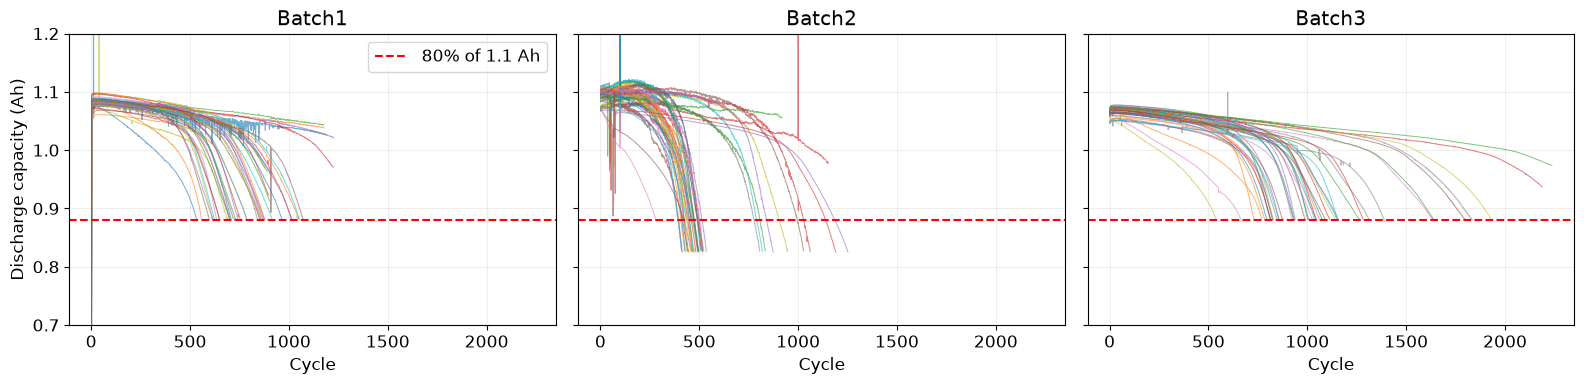

In [37]:
# Batch1의 QD 기록
qd_tables = [
    df[["cell_id", "cycle", "QD"]].assign(batch="Batch1")
]

# Batch2·3에서 사이클별 방전 용량만 읽기
for batch_name, filename in batch_files.items():
    with h5py.File(data_dir / filename, "r") as f:
        references = f["batch"]["summary"][()].reshape(-1)

        for cell_id, reference in enumerate(references):
            summary = f[reference]

            cycle = np.asarray(summary["cycle"][()]).reshape(-1)
            qd = np.asarray(summary["QDischarge"][()]).reshape(-1)

            if len(cycle) != len(qd):
                raise ValueError(
                    f"{batch_name} Cell {cell_id}: 기록 길이가 다릅니다."
                )

            qd_tables.append(pd.DataFrame({
                "batch": batch_name,
                "cell_id": cell_id,
                "cycle": cycle,
                "QD": qd,
            }))

df_qd_batches = pd.concat(qd_tables, ignore_index=True)

# 배치별 곡선 비교
fig, axes = plt.subplots(
    1, 3, figsize=(16, 4), sharex=True, sharey=True
)

for ax, name in zip(axes, ["Batch1", "Batch2", "Batch3"]):
    batch_rows = df_qd_batches[df_qd_batches["batch"] == name]

    for cid, cell_rows in batch_rows.groupby("cell_id"):
        cell_rows = cell_rows.sort_values("cycle")
        ax.plot(
            cell_rows["cycle"], cell_rows["QD"],
            linewidth=0.7, alpha=0.6
        )

    ax.axhline(
        0.88, color="red", linestyle="--",
        label="80% of 1.1 Ah"
    )
    ax.set(title=name, xlabel="Cycle")
    ax.set_ylim(0.7, 1.2)
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Discharge capacity (Ah)")
axes[0].legend()
plt.tight_layout()
plt.show()

| 배치 | 그래프에서 보이는 특징 |
|---|---|
| **Batch1** | 많은 셀이 약 500~1,000회 사이에 0.88 Ah 부근까지 감소 |
| **Batch2** | 많은 셀이 약 400~500회 부근에 빠르게 감소하고, 일부는 더 오래 유지 |
| **Batch3** | 감소 시점이 넓게 분포하며, 2,000회 이후까지 높은 용량을 유지하는 셀도 보임 |

Batch2는 대체로 1.1 Ah 부근, Batch3는 1.06~1.08 Ah 부근에서 시작. 따라서 배치 간 초기 측정값의 차이도 살펴볼 필요가 있음

배치마다 용량 감소 시점과 초기 용량 분포가 다르다

,특징_계산수,수명값_있는_셀수
batch,,
Batch1,46,46
Batch2,47,39
Batch3,46,44


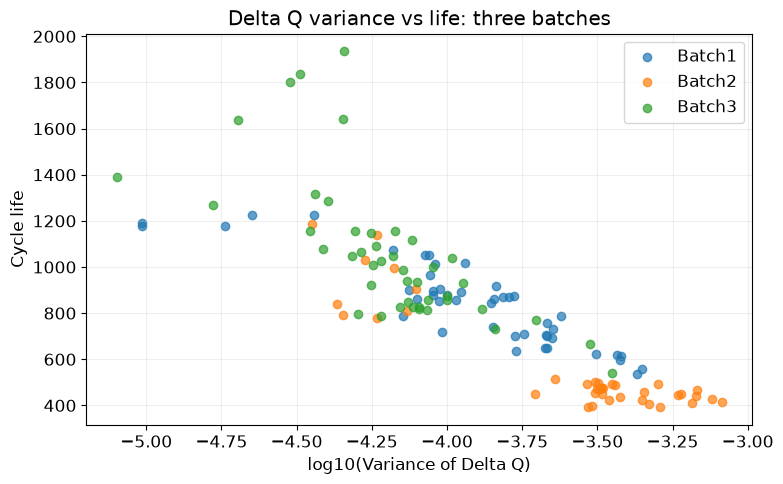

,batch,비교_셀수,Pearson_r
0,Batch1,46,-0.886
1,Batch2,39,-0.902
2,Batch3,44,-0.702


In [38]:
# Batch1에서 계산한 특징 포함
delta_tables = [df_delta.assign(batch="Batch1")]
skipped = []

life_lookup = df_life_batches.set_index(
    ["batch", "cell_id"]
)["cycle_life"]

reference_voltage = np.asarray(cell0["Vdlin"]).reshape(-1)

for batch_name, filename in batch_files.items():
    rows = []

    with h5py.File(data_dir / filename, "r") as f:
        b = f["batch"]
        summary_refs = b["summary"][()].reshape(-1)
        cycle_refs = b["cycles"][()].reshape(-1)
        voltage_refs = b["Vdlin"][()].reshape(-1)

        for cid in range(len(summary_refs)):
            try:
                summary = f[summary_refs[cid]]
                numbers = summary["cycle"][()].reshape(-1)

                i10 = np.flatnonzero(numbers == 10)[0]
                i100 = np.flatnonzero(numbers == 100)[0]

                cycle_group = f[cycle_refs[cid]]
                q_refs = cycle_group["Qdlin"][()].reshape(-1)

                q_curves = []
                for position in [i10, i100]:
                    dataset = f[q_refs[position]]

                    if dataset.attrs.get("MATLAB_empty", 0):
                        raise ValueError("Qdlin이 비어 있음")

                    q_curves.append(
                        np.asarray(dataset[()], dtype=float).reshape(-1)
                    )

                q10, q100 = q_curves
                voltage = f[voltage_refs[cid]][()].reshape(-1)

                if not (
                    q10.shape == q100.shape
                    == voltage.shape == reference_voltage.shape
                ):
                    raise ValueError("곡선 길이가 다름")

                if not np.allclose(voltage, reference_voltage):
                    raise ValueError("전압 축이 Batch1과 다름")

                if not (
                    np.isfinite(q10).all()
                    and np.isfinite(q100).all()
                ):
                    raise ValueError("곡선에 결측값 또는 무한대가 있음")

                delta = q100 - q10
                variance = np.var(delta)

                rows.append({
                    "batch": batch_name,
                    "cell_id": cid,
                    "cycle_life": life_lookup.loc[(batch_name, cid)],
                    "delta_Q_mean": np.mean(delta),
                    "delta_Q_min": np.min(delta),
                    "delta_Q_var": variance,
                    "log10_delta_Q_var": (
                        np.log10(variance) if variance > 0 else np.nan
                    ),
                })

            except (KeyError, IndexError, TypeError, ValueError) as error:
                skipped.append((batch_name, cid, str(error)))

    delta_tables.append(pd.DataFrame(rows))

df_delta_batches = pd.concat(delta_tables, ignore_index=True)

display(
    df_delta_batches.groupby("batch").agg(
        특징_계산수=("cell_id", "size"),
        수명값_있는_셀수=("cycle_life", "count")
    )
)

if skipped:
    print("계산하지 못한 셀:", skipped)


# 배치별 산점도와 상관계수
fig, ax = plt.subplots(figsize=(8, 5))
correlation_rows = []

for name, group in df_delta_batches.groupby("batch"):
    valid = group.dropna(
        subset=["cycle_life", "log10_delta_Q_var"]
    )

    ax.scatter(
        valid["log10_delta_Q_var"],
        valid["cycle_life"],
        label=name, alpha=0.7
    )

    correlation_rows.append({
        "batch": name,
        "비교_셀수": len(valid),
        "Pearson_r": valid["log10_delta_Q_var"].corr(
            valid["cycle_life"]
        ),
    })

ax.set(
    xlabel="log10(Variance of Delta Q)",
    ylabel="Cycle life",
    title="Delta Q variance vs life: three batches"
)
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

display(pd.DataFrame(correlation_rows).round(3))

| 배치 | 비교 셀 수 | 상관계수 |
|---|---:|---:|
| Batch1 | 46 | **−0.886** |
| Batch2 | 39 | **−0.902** |
| Batch3 | 44 | **−0.702** |

ΔQ 로그 분산과 수명의 음의 관계가 세 배치 모두에서 나타남

다만 Batch3은 같은 분산 부근에서도 수명이 더 넓게 퍼져 있어. 로그 분산 하나만으로 설명되지 않는 차이가 보임



초기 100사이클의 온도·충전 시간·IR을 배치별로 비교

In [39]:
# 1. 초기 100사이클의 필요한 측정값 모으기
columns = ["cell_id", "cycle", "QD", "IR", "Tavg", "Tmax", "chargetime"]

early_tables = [
    df.loc[df["cycle"].between(1, 100), columns]
      .assign(batch="Batch1")
]

field_map = {
    "cycle": "cycle",
    "QD": "QDischarge",
    "IR": "IR",
    "Tavg": "Tavg",
    "Tmax": "Tmax",
    "chargetime": "chargetime",
}

for batch_name, filename in batch_files.items():
    with h5py.File(data_dir / filename, "r") as f:
        references = f["batch"]["summary"][()].reshape(-1)

        for cid, reference in enumerate(references):
            summary = f[reference]

            values = {
                column: np.asarray(
                    summary[field][()], dtype=float
                ).reshape(-1)
                for column, field in field_map.items()
            }

            cell_rows = pd.DataFrame(values)
            cell_rows = cell_rows[
                cell_rows["cycle"].between(1, 100)
            ].copy()

            cell_rows["batch"] = batch_name
            cell_rows["cell_id"] = cid
            early_tables.append(cell_rows)

df_early_batches = pd.concat(early_tables, ignore_index=True)

# 수명값이 있는 셀만 선택
df_early_valid = df_early_batches.merge(
    df_life_valid[["batch", "cell_id", "cycle_life"]],
    on=["batch", "cell_id"],
    how="inner",
    validate="many_to_one"
)

# 측정값이 모두 0인 빈 기록 제외
measurements = ["QD", "IR", "Tavg", "Tmax", "chargetime"]
empty_record = df_early_valid[measurements].eq(0).all(axis=1)
df_early_valid = df_early_valid.loc[~empty_record].copy()

# IR=0은 결측으로 표시
df_early_valid["IR"] = df_early_valid["IR"].replace(0, np.nan)


# 2. 배터리마다 한 행으로 요약
df_early_features = (
    df_early_valid.groupby(["batch", "cell_id"])
    .agg(
        cycle_life=("cycle_life", "first"),
        mean_IR=("IR", "mean"),
        mean_Tavg=("Tavg", "mean"),
        mean_Tmax=("Tmax", "mean"),
        mean_chargetime=("chargetime", "mean"),
        valid_IR_records=("IR", "count"),
    )
    .reset_index()
)

# 기존 ΔQ 특징 추가
df_early_features = df_early_features.merge(
    df_delta_batches[["batch", "cell_id", "log10_delta_Q_var"]],
    on=["batch", "cell_id"],
    how="left",
    validate="one_to_one"
)

# IR 평균을 계산할 수 있는 셀 수 확인
display(
    df_early_features.groupby("batch").agg(
        수명값_있는_셀수=("cell_id", "size"),
        IR값_있는_셀수=("mean_IR", "count")
    )
)


# 3. 배치별 특징의 평균과 수명 상관 비교
feature_columns = [
    "mean_IR", "mean_Tavg", "mean_Tmax",
    "mean_chargetime", "log10_delta_Q_var"
]

print("배치별 초기 특징의 평균")
display(
    df_early_features.groupby("batch")[feature_columns]
    .mean().round(4)
)

correlation_table = pd.DataFrame({
    name: group[["cycle_life"] + feature_columns]
        .corr()["cycle_life"]
        .drop("cycle_life")
    for name, group in df_early_features.groupby("batch")
})

print("배치별 수명과의 Pearson 상관계수")
display(correlation_table.round(3))

,수명값_있는_셀수,IR값_있는_셀수
batch,,
Batch1,46,46
Batch2,39,33
Batch3,44,44


배치별 초기 특징의 평균


,mean_IR,mean_Tavg,mean_Tmax,mean_chargetime,log10_delta_Q_var
batch,,,,,
Batch1,0.0166,32.6166,35.8683,11.2811,-3.9234
Batch2,0.0164,32.8983,36.1630,20.2103,-3.5963
Batch3,0.0153,34.1695,36.8521,10.1816,-4.1942


배치별 수명과의 Pearson 상관계수


,Batch1,Batch2,Batch3
mean_IR,0.218,-0.627,0.190
mean_Tavg,-0.482,0.425,-0.022
mean_Tmax,-0.404,0.019,-0.106
mean_chargetime,0.577,0.087,0.637
log10_delta_Q_var,-0.886,-0.902,-0.702


In [40]:
df_early_features.groupby("batch")["mean_chargetime"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
batch,,,,,,,,
Batch1,46.0,11.28,1.41,8.99,10.16,11.15,11.96,15.08
Batch2,39.0,20.21,17.35,10.04,10.17,10.17,29.75,49.48
Batch3,44.0,10.18,0.34,10.04,10.04,10.04,10.05,11.04


Batch2의 셀별 평균 충전시간 분포는 일부 큰 값으로 오른쪽으로 길어졌다. 셀별 평균의 배치 평균은 20.21, 배치 중앙값은 약 10.17이다. 다음에는 셀 안의 기록을 확인해 평균 왜곡의 원인을 살펴본다.

In [41]:
df_early_valid.loc[
    df_early_valid["batch"] == "Batch2"
].groupby("cell_id")["chargetime"].agg(
    ["mean", "median", "max"]
).sort_values("mean", ascending=False).head(10).round(2)

,mean,median,max
cell_id,,,
14,49.48,10.24,3934.71
30,49.43,10.18,3933.40
26,49.43,10.18,3933.12
41,49.42,10.18,3933.62
28,49.41,10.17,3933.74
46,49.41,10.17,3933.84
20,49.40,10.17,3932.59
34,49.28,10.04,3934.12
32,49.28,10.04,3933.46


충전 시간 평균이 일부 극단적으로 긴 기록에 끌려 올라간 것

기존 충전 시간 평균의 해석은 보류하고, 중앙값을 추가해서 비교

In [42]:
median_ct = (
    df_early_valid.groupby(["batch", "cell_id"])["chargetime"]
    .median()
    .rename("median_chargetime")
    .reset_index()
)

df_early_features = (
    df_early_features
    .drop(columns="median_chargetime", errors="ignore")
    .merge(
        median_ct,
        on=["batch", "cell_id"],
        validate="one_to_one"
    )
)

display(pd.DataFrame({
    name: group[
        ["cycle_life", "mean_chargetime", "median_chargetime"]
    ].corr()["cycle_life"].drop("cycle_life")
    for name, group in df_early_features.groupby("batch")
}).round(3))

,Batch1,Batch2,Batch3
mean_chargetime,0.577,0.087,0.637
median_chargetime,0.744,-0.919,0.638


Batch2: 충전 시간 중앙값 순서로 정렬


,batch,charging_policy,n,mean_life,std_life,median_chargetime,mean_Tavg
28,Batch2,4.8C(80%)-4.8C-newstructure,3,871.667,137.191,10.037,33.284
31,Batch2,5.2C(58%)-4C-newstructure,3,961.667,157.621,10.040,33.431
33,Batch2,5.6C(26%)-4.5C-newstructure,3,991.333,197.561,10.040,34.431
27,Batch2,4.8C(80%)-4.8C,5,483.600,30.320,10.171,31.943
30,Batch2,5.2C(58%)-4C,4,477.750,18.464,10.173,32.367
25,Batch2,4.65C(44%)-5C,2,482.500,23.335,10.174,32.628
29,Batch2,5.2C(50%)-4.25C,5,454.000,20.917,10.175,32.846
34,Batch2,6C(60%)-3C,2,400.000,11.314,10.175,33.184
24,Batch2,3.6C(9%)-5C,2,394.500,2.121,10.177,33.340
32,Batch2,5.6C(26%)-4.5C,6,448.500,29.126,10.177,32.956


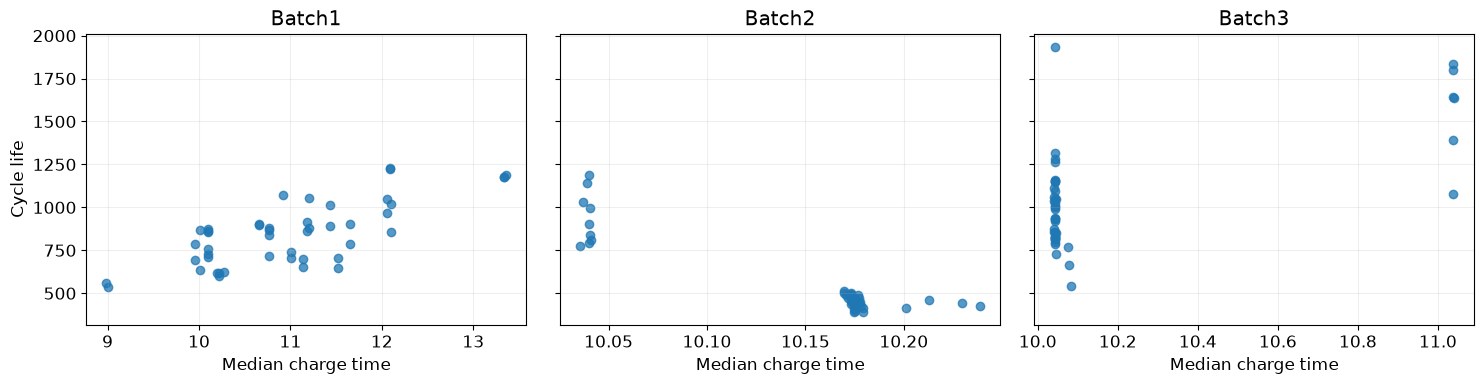

In [43]:
# 1. 배치별 충전 정책 가져오기
policy_tables = [
    df.drop_duplicates("cell_id")[
        ["cell_id", "charging_policy"]
    ].assign(batch="Batch1")
]

for batch_name, filename in batch_files.items():
    rows = []

    with h5py.File(data_dir / filename, "r") as f:
        references = f["batch"]["policy_readable"][()].reshape(-1)

        for cid, reference in enumerate(references):
            characters = f[reference][()].reshape(-1)
            policy = "".join(chr(int(x)) for x in characters)

            rows.append({
                "batch": batch_name,
                "cell_id": cid,
                "charging_policy": policy,
            })

    policy_tables.append(pd.DataFrame(rows))

df_policies = pd.concat(policy_tables, ignore_index=True)

df_policy_features = df_early_features.merge(
    df_policies,
    on=["batch", "cell_id"],
    how="left",
    validate="one_to_one"
)


# 2. 정책별 셀 수·수명·충전 시간 요약
policy_summary = (
    df_policy_features.groupby(["batch", "charging_policy"])
    .agg(
        n=("cell_id", "size"),
        mean_life=("cycle_life", "mean"),
        std_life=("cycle_life", "std"),
        median_chargetime=("median_chargetime", "median"),
        mean_Tavg=("mean_Tavg", "mean"),
    )
    .reset_index()
)

print("Batch2: 충전 시간 중앙값 순서로 정렬")
display(
    policy_summary.loc[policy_summary["batch"] == "Batch2"]
    .sort_values("median_chargetime")
    .round(3)
)


# 3. 각 셀의 충전 시간 중앙값과 수명 비교
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, name in zip(axes, ["Batch1", "Batch2", "Batch3"]):
    group = df_policy_features[df_policy_features["batch"] == name]

    ax.scatter(
        group["median_chargetime"],
        group["cycle_life"],
        alpha=0.75
    )
    ax.set(title=name, xlabel="Median charge time")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Cycle life")
plt.tight_layout()
plt.show()

Batch2의 반대 방향 상관을 설명할 단서. newstructure 표기가 있는 셀들이 별도 집단을 이루고 있음

| 충전 설정 | 일반 표기 평균 수명 | `newstructure` 평균 수명 |
|---|---:|---:|
| `4.8C(80%)-4.8C` | 484회 | 872회 |
| `5.2C(58%)-4C` | 478회 | 962회 |
| `5.6C(26%)-4.5C` | 449회 | 991회 |

newstructure 집단은 충전 시간 중앙값이 약 10.04, 나머지는 약 10.17~10.22. 시간 차이는 작지만 수명 차이는 큼

따라서 Batch2의 r=−0.919는 충전 시간 자체의 효과뿐 아니라, 이 두 집단의 차이를 반영했을 가능성이 큼. “조금 더 빨리 충전해서 오래 갔다”라고 해석하면 안된다.

Batch3도 약 10과 11 부근의 두 집단이 보임. 충전 시간은 배치별 집단 구분과 연결될 수 있으니, 독립적인 수명 원인으로 해석하기보다 보조 입력 후보로 관리

,n,mean_life,std_life,charge_time_min,charge_time_max
experiment_group,,,,,
newstructure 표시,9,941.5556,153.5791,10.0356,10.0409
newstructure 표시 없음,30,453.0000,34.7692,10.1698,10.2387


집단 내부의 Pearson 상관계수


,group,n,charge_time_vs_life,delta_Q_vs_life
0,newstructure 표시,9,0.080,-0.294
1,newstructure 표시 없음,30,-0.255,-0.386


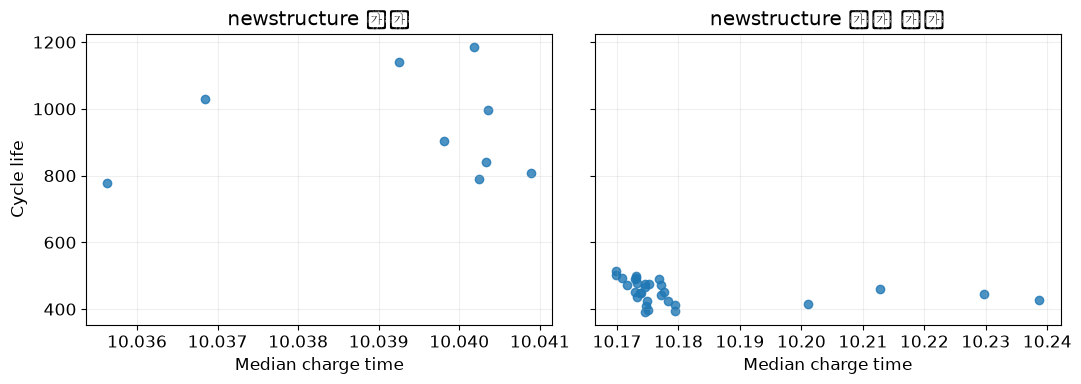

In [44]:
# 원래 특징표를 유지하고, 실험 구분 표시 추가
df_policy_features = df_policy_features.copy()

df_policy_features["has_newstructure"] = (
    df_policy_features["charging_policy"]
    .str.contains("newstructure", case=False, na=False)
)

b2 = df_policy_features.loc[
    df_policy_features["batch"] == "Batch2"
].copy()

b2["experiment_group"] = np.where(
    b2["has_newstructure"],
    "newstructure 표시",
    "newstructure 표시 없음"
)


# 1. 집단별 수명과 충전 시간 범위
display(
    b2.groupby("experiment_group").agg(
        n=("cell_id", "size"),
        mean_life=("cycle_life", "mean"),
        std_life=("cycle_life", "std"),
        charge_time_min=("median_chargetime", "min"),
        charge_time_max=("median_chargetime", "max"),
    ).round(4)
)


# 2. 집단 내부의 수명 상관 비교
rows = []

for name, group in b2.groupby("experiment_group"):
    rows.append({
        "group": name,
        "n": len(group),
        "charge_time_vs_life": group["median_chargetime"].corr(
            group["cycle_life"]
        ),
        "delta_Q_vs_life": group["log10_delta_Q_var"].corr(
            group["cycle_life"]
        ),
    })

print("집단 내부의 Pearson 상관계수")
display(pd.DataFrame(rows).round(3))


# 3. 두 집단을 따로 그리기
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, (name, group) in zip(
    axes, b2.groupby("experiment_group")
):
    ax.scatter(
        group["median_chargetime"],
        group["cycle_life"],
        alpha=0.8
    )
    ax.set(title=name, xlabel="Median charge time")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Cycle life")
plt.tight_layout()
plt.show()

| 수명과의 상관 | Batch2 전체 | `newstructure` 9개 | 표기 없는 30개 |
|---|---:|---:|---:|
| 충전 시간 중앙값 | **−0.919** | +0.080 | −0.255 |
| ΔQ 로그 분산 | **−0.902** | −0.294 | −0.386 |


집단을 나누니 두 특징 모두 관계가 약해짐. 평균 수명도 942회와 453회로 크게 다름.

Batch2 전체에서 충전 시간과 ΔQ 로그 분산은 수명과 강하게 연결되지만, 그 관계에는 실험 집단 간 차이가 상당히 포함돼 있다.

실험 집단을 구분해 해석할 필요가 있다.

# DAY1 정리

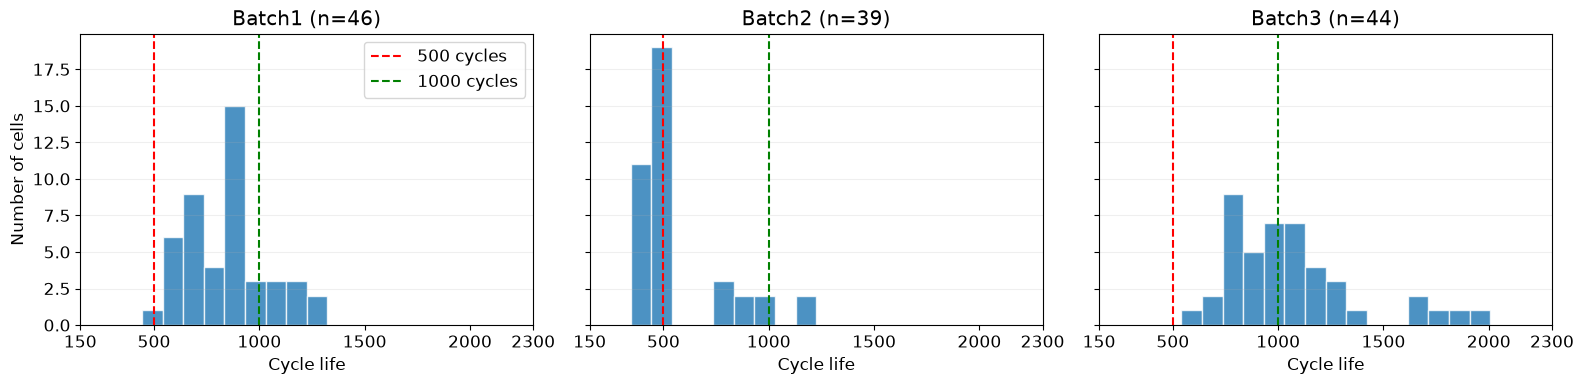

배치별 수명 통계 — short: <500 / long: >1000


,n,mean,median,std,min,max,short_n,long_n,short_pct,long_pct
batch,,,,,,,,,,
Batch1,46,844.72,858.5,184.63,534.0,1227.0,0,10,0.00,21.74
Batch2,39,565.74,472.0,222.20,392.0,1186.0,28,3,71.79,7.69
Batch3,44,1059.66,1005.5,313.87,541.0,1935.0,0,23,0.00,52.27


각 배치의 최단 수명 3개 셀 — 원인 비교 대상


,batch,cell_id,cycle_life,charging_policy
0,Batch1,20,534.0,5.4C(80%)-5.4C
1,Batch1,21,559.0,5.4C(80%)-5.4C
2,Batch1,45,599.0,8C(35%)-3.6C
3,Batch2,19,392.0,6C(60%)-3C
4,Batch2,6,393.0,3.6C(9%)-5C
5,Batch2,15,396.0,3.6C(9%)-5C
6,Batch3,28,541.0,3.7C(31%)-5.9C-newstructure
7,Batch3,6,667.0,3.7C(31%)-5.9C-newstructure
8,Batch3,31,731.0,5.9C(60%)-3.1C-newstructure


In [45]:
import numpy as np
import matplotlib.pyplot as plt

batch_order = ["Batch1", "Batch2", "Batch3"]

# 수명값이 있는 셀만 사용
life = df_life_valid[["batch", "cell_id", "cycle_life"]].copy()

# 1. 동일한 전압이 아니라, 동일한 수명 범위와 bin으로 비교
bins = np.linspace(150, 2300, 23)

fig, axes = plt.subplots(
    1, 3, figsize=(16, 4), sharex=True, sharey=True
)

for ax, batch_name in zip(axes, batch_order):
    values = life.loc[
        life["batch"] == batch_name, "cycle_life"
    ]

    ax.hist(values, bins=bins, alpha=0.8, edgecolor="white")
    ax.axvline(500, color="red", linestyle="--", label="500 cycles")
    ax.axvline(1000, color="green", linestyle="--", label="1000 cycles")

    ax.set_title(f"{batch_name} (n={len(values)})")
    ax.set_xlim(150, 2300)
    ax.set_xticks([150, 500, 1000, 1500, 2000, 2300])
    ax.set_xlabel("Cycle life")
    ax.grid(axis="y", alpha=0.2)

axes[0].set_ylabel("Number of cells")
axes[0].legend()
plt.tight_layout()
plt.show()

# 2. 배치별 수명 통계와 장·단수명 비율
df_life_summary = (
    life.groupby("batch")["cycle_life"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max",
        short_n=lambda s: (s < 500).sum(),
        long_n=lambda s: (s > 1000).sum(),
    )
    .reindex(batch_order)
)

df_life_summary["short_pct"] = (
    100 * df_life_summary["short_n"] / df_life_summary["n"]
)
df_life_summary["long_pct"] = (
    100 * df_life_summary["long_n"] / df_life_summary["n"]
)

print("배치별 수명 통계 — short: <500 / long: >1000")
display(df_life_summary.round(2))

# 3. 각 배치에서 상대적으로 가장 짧은 3개 셀과 충전 정책
df_short_candidates = (
    life.sort_values(["batch", "cycle_life"])
    .groupby("batch", sort=False)
    .head(3)
    .merge(
        df_policies[["batch", "cell_id", "charging_policy"]],
        on=["batch", "cell_id"],
        how="left",
        validate="one_to_one",
    )
)

print("각 배치의 최단 수명 3개 셀 — 원인 비교 대상")
display(
    df_short_candidates[
        ["batch", "cell_id", "cycle_life", "charging_policy"]
    ].reset_index(drop=True)
)

| 배치 | 분포 특징 | 단수명 `<500` | 장수명 `>1000` |
|---|---|---:|---:|
| Batch1 | 중앙값 858.5, 중간 수명대에 집중 | 0% | 21.74% |
| Batch2 | 중앙값 472, 짧은 수명 집단과 긴 수명 집단이 나뉨 | 71.79% | 7.69% |
| Batch3 | 중앙값 1005.5, 장수명 쪽까지 넓게 분포 | 0% | 52.27% |


Batch1: 가장 짧은 두 셀이 모두 5.4C(80%)-5.4C. 같은 정책에서 짧은 수명이 반복된다는 단서


Batch2: 6C(60%)-3C, 3.6C(9%)-5C에서 짧은 셀이 나옴. 높은 첫 단계 전류뿐 아니라 두 번째 단계 전류도 함께 비교



Batch1: 중간 정도 수명인 배터리가 많다. 중앙값 약 859사이클.

Batch2: 빨리 수명이 끝나는 배터리가 많다. 약 72%가 500사이클 미만. 일부 오래가는 셀은 별도 실험 집단과 연결돼 있음.

Batch3: 오래가는 배터리가 많다. 약 52%가 1000사이클을 넘고, 셀 사이 수명 차이도 큼


모델링 결론 : Batch1으로 학습한 모델이 Batch2·3에서도 잘 맞을지는 따로 확인. 특히 Batch1에는 500사이클 미만 사례가 없어서, Batch2의 짧은 수명을 잘 예측하는지가 중요한 확인 대상

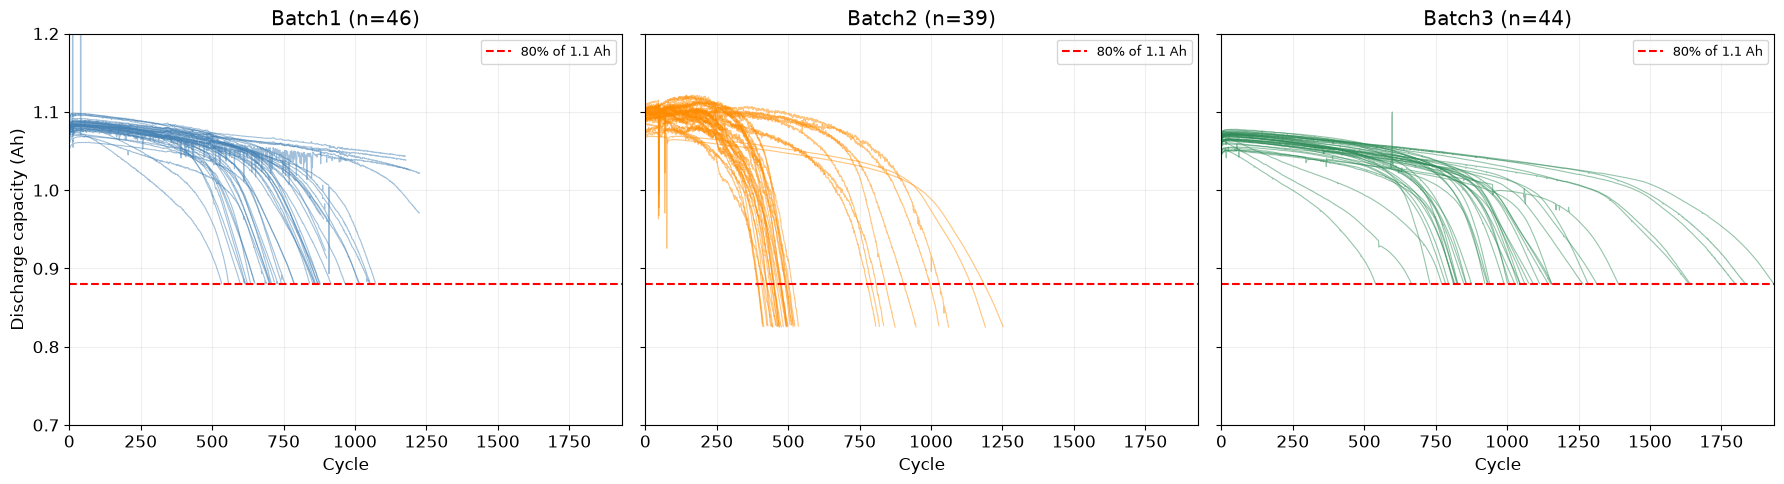

In [47]:
import matplotlib.pyplot as plt

# 수명값이 있는 셀만 남기기
df_qd_valid = df_qd_batches.merge(
    df_life_valid[["batch", "cell_id"]],
    on=["batch", "cell_id"],
    how="inner",
    validate="many_to_one",
)

batch_order = ["Batch1", "Batch2", "Batch3"]
colors = ["steelblue", "darkorange", "seagreen"]

fig, axes = plt.subplots(
    1, 3, figsize=(18, 5), sharex=True, sharey=True
)

for ax, batch_name, color in zip(axes, batch_order, colors):
    batch_data = df_qd_valid.loc[
        df_qd_valid["batch"] == batch_name
    ]

    for cell_id, curve in batch_data.groupby("cell_id"):
        curve = curve.sort_values("cycle")
        curve = curve.loc[
            curve["QD"].notna() & (curve["QD"] > 0)
        ]

        ax.plot(
            curve["cycle"], curve["QD"],
            color=color, linewidth=0.8, alpha=0.5,
        )

    ax.axhline(
        0.88, color="red", linestyle="--",
        label="80% of 1.1 Ah",
    )

    ax.set_title(
        f"{batch_name} (n={batch_data['cell_id'].nunique()})"
    )
    ax.set_xlabel("Cycle")
    ax.set_xlim(0, df_qd_valid["cycle"].max())
    ax.set_ylim(0.7, 1.2)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=9)

axes[0].set_ylabel("Discharge capacity (Ah)")
plt.tight_layout()
plt.show()

| 관찰한 내용 | 모델링에 연결할 결론 |
|---|---|
| 초기에는 같은 배치의 셀들이 비슷한 용량에서 시작함 | **초기 용량 하나만으로 수명을 구분하기 어려움.** 초기 용량의 변화량·감소 기울기를 후보로 사용 |
| 처음에는 완만하다가 후기에 급격히 감소하는 셀이 많음 | **초기의 작은 변화에서 이후 열화의 단서를 찾는 것이 중요함.** 앞서 수명과 강한 관계를 보인 로그 ΔQ 분산을 대표 후보로 선택 |
| Batch2는 일찍 감소하는 셀이 많고, Batch3는 오래 유지되는 셀이 많음 | **배치마다 특성이 다름.** Batch1에서 학습한 모델을 다른 배치에서도 평가해야 함 |
| 일부 곡선에 순간적인 급락·스파이크가 보임 | 평균·최솟값은 영향을 받을 수 있으므로, **중앙값 같은 안정적인 요약값도 활용** |

배터리 용량은 일정한 속도로 감소하지 않으며, 일부 셀에서는 감소가 가속되는 knee가 관찰된다. 짧은 수명 셀은 이러한 가속이 일찍 나타나고, 긴 수명 셀은 완만한 감소 구간을 오래 유지하는 경향이 있다.

| 배치 | Knee에 대한 관찰 |
|---|---|
| **Batch1** | 여러 셀이 약 **400~800사이클 부근부터 감소가 가속**. 기록 끝까지 뚜렷한 꺾임이 안 보이는 셀도 있음. |
| **Batch2** | 많은 셀이 약 **200~400사이클 부근에서 일찍 가속**. 일부 셀은 훨씬 늦게 꺾인다. |
| **Batch3** | 가속 시점이 다양하고, 오래 유지되는 셀은 **1500사이클 부근 이후**에 꺾이는 모습도 보임. |

모델 전략 결론 :  “초기 용량의 크기보다 초기 변화 정보를 활용하자”


위 시점은 육안 탐색 범위이며 자동 검출 결과가 아니다. 후기 전체 기록에서 확인한 실제 knee는 100사이클 예측의 입력에 넣지 않는다.


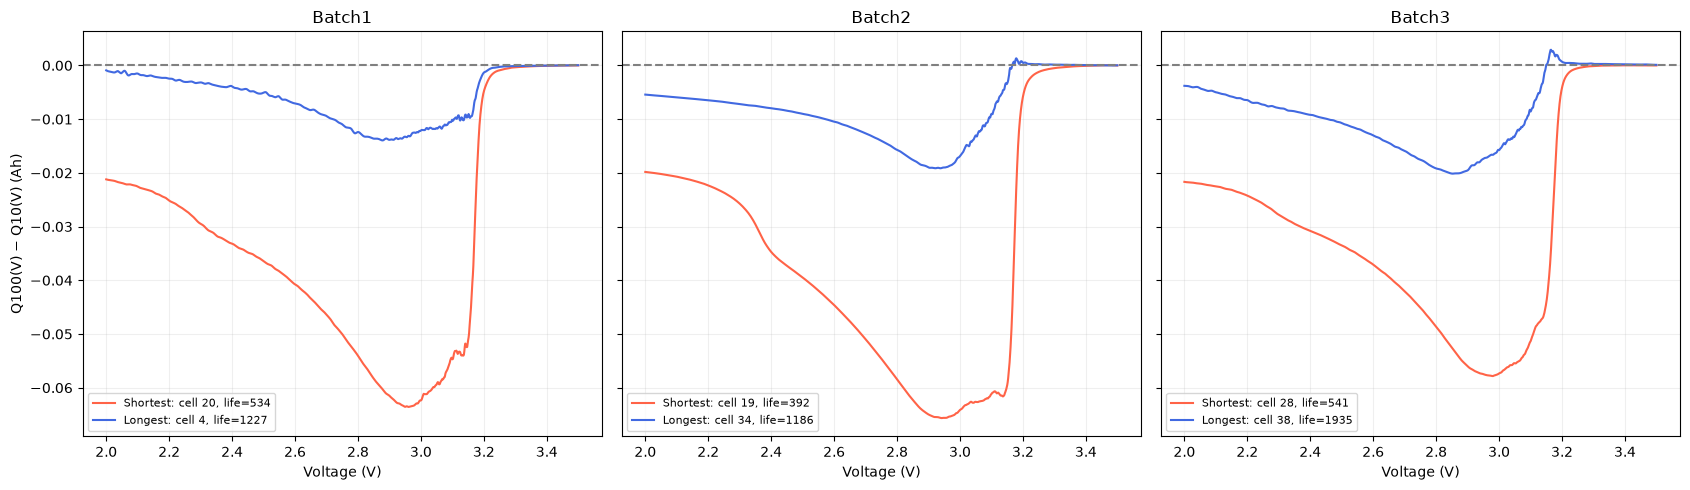

대표 셀의 ΔQ 특징


,batch,cell_id,group,cycle_life,delta_Q_mean,delta_Q_min,delta_Q_var,log10_delta_Q_var
0,Batch1,20,Shortest,534.0,-0.032796,-0.063580,0.000429,-3.367237
1,Batch1,4,Longest,1227.0,-0.005750,-0.013958,0.000023,-4.647744
2,Batch2,19,Shortest,392.0,-0.034308,-0.065652,0.000511,-3.291958
3,Batch2,34,Longest,1186.0,-0.008120,-0.019143,0.000036,-4.448585
4,Batch3,28,Shortest,541.0,-0.030256,-0.057831,0.000353,-3.451658
5,Batch3,38,Longest,1935.0,-0.008693,-0.020147,0.000045,-4.342053


In [3]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

files = {
    "Batch1": "2017-05-12_batchdata_updated_struct_errorcorrect.mat",
    "Batch2": "2018-02-20_batchdata_updated_struct_errorcorrect.mat",
    "Batch3": "2018-04-12_batchdata_updated_struct_errorcorrect.mat",
}

batch_order = ["Batch1", "Batch2", "Batch3"]
colors = {"Shortest": "tomato", "Longest": "royalblue"}

# 각 배치의 수명값이 있는 셀에서 최단·최장 셀 선택
representatives = []
for batch_name, group in df_life_valid.groupby("batch"):
    ordered = group.sort_values(["cycle_life", "cell_id"])
    for label, row in [("Shortest", ordered.iloc[0]), ("Longest", ordered.iloc[-1])]:
        representatives.append({"batch": batch_name, "cell_id": row.cell_id,
                               "cycle_life": row.cycle_life, "group": label})
df_representative = pd.DataFrame(representatives)

rows = []
delta_examples = {}

fig, axes = plt.subplots(
    1, 3, figsize=(17, 5), sharex=True, sharey=True
)

for ax, batch_name in zip(axes, batch_order):
    selected = df_representative.loc[
        df_representative["batch"] == batch_name
    ]

    # 전체 MAT 파일을 메모리에 올리지 않고 필요한 배열만 읽기
    with h5py.File(data_dir / files[batch_name], "r") as f:
        batch_group = f["batch"]

        for _, cell in selected.iterrows():
            cell_id = int(cell["cell_id"])

            summary = f[batch_group["summary"][cell_id, 0]]
            cycles = f[batch_group["cycles"][cell_id, 0]]

            # 실제 사이클 번호와 배열 위치 연결
            cycle_numbers = summary["cycle"][()].ravel()
            lookup = {
                int(number): index
                for index, number in enumerate(cycle_numbers)
            }

            q10 = f[cycles["Qdlin"][lookup[10], 0]][()].ravel()
            q100 = f[cycles["Qdlin"][lookup[100], 0]][()].ravel()

            voltage = f[
                batch_group["Vdlin"][cell_id, 0]
            ][()].ravel()

            delta_q = q100 - q10
            variance = np.var(delta_q)

            delta_examples[(batch_name, cell_id)] = {
                "voltage": voltage,
                "delta_Q": delta_q,
            }

            rows.append({
                "batch": batch_name,
                "cell_id": cell_id,
                "group": cell["group"],
                "cycle_life": cell["cycle_life"],
                "delta_Q_mean": np.mean(delta_q),
                "delta_Q_min": np.min(delta_q),
                "delta_Q_var": variance,
                "log10_delta_Q_var": (
                    np.log10(variance) if variance > 0 else np.nan
                ),
            })

            ax.plot(
                voltage,
                delta_q,
                color=colors[cell["group"]],
                linewidth=1.5,
                label=(
                    f"{cell['group']}: cell {cell_id}, "
                    f"life={int(cell['cycle_life'])}"
                ),
            )

    ax.axhline(0, color="gray", linestyle="--")
    ax.set_title(batch_name)
    ax.set_xlabel("Voltage (V)")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Q100(V) − Q10(V) (Ah)")
plt.tight_layout()
plt.show()

df_delta_representative = pd.DataFrame(rows)

print("대표 셀의 ΔQ 특징")
display(
    df_delta_representative
    .sort_values(["batch", "cycle_life"])
    .reset_index(drop=True)
    .round(6)
)

초기 총용량이 비슷해도 방전 곡선의 변화에는 차이가 나타난다. ΔQ 평균·최솟값·로그 분산은 이러한 차이를 수치로 표현하므로 수명 예측 특징 후보로 사용할 수 있다.

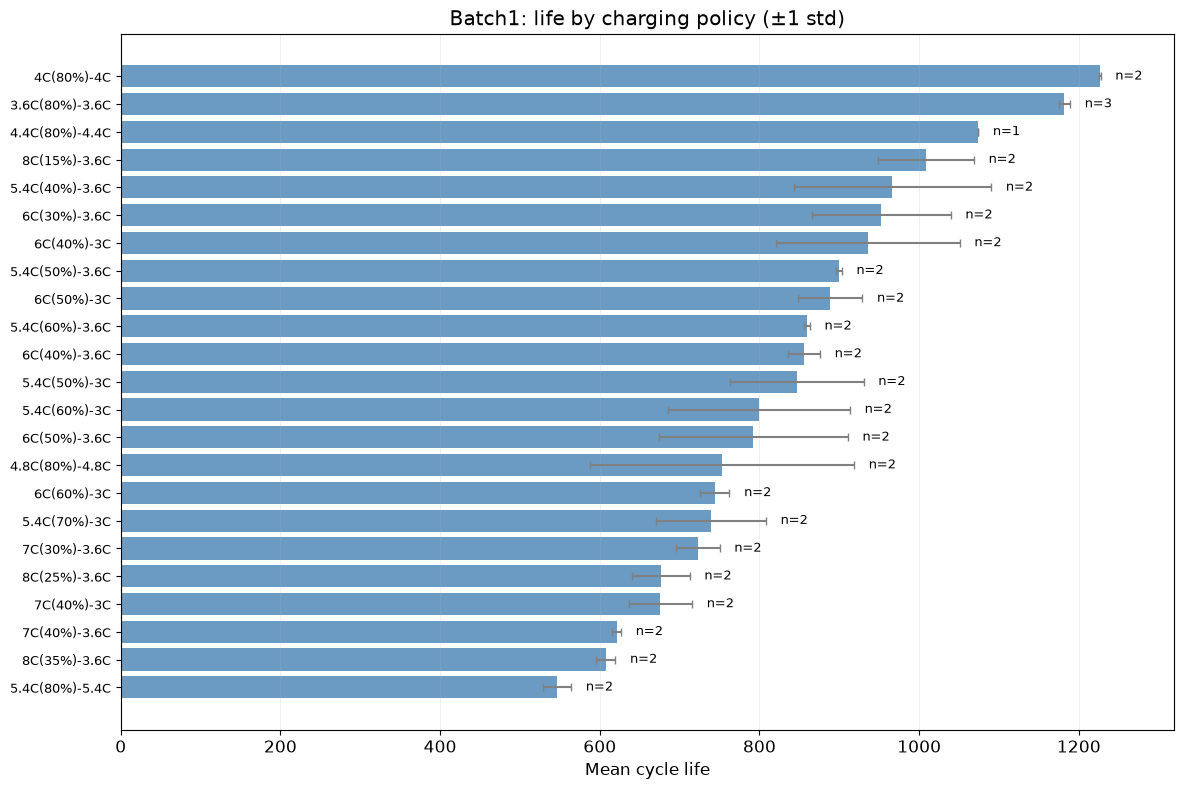

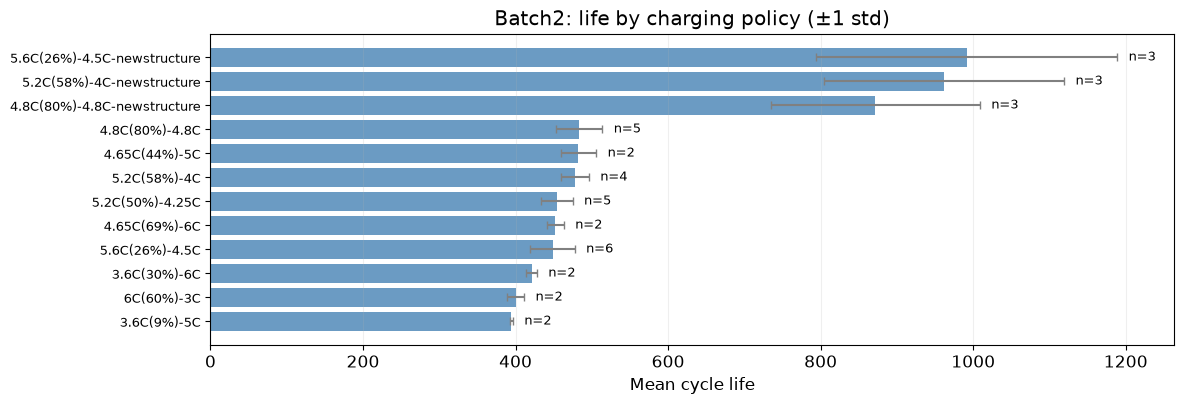

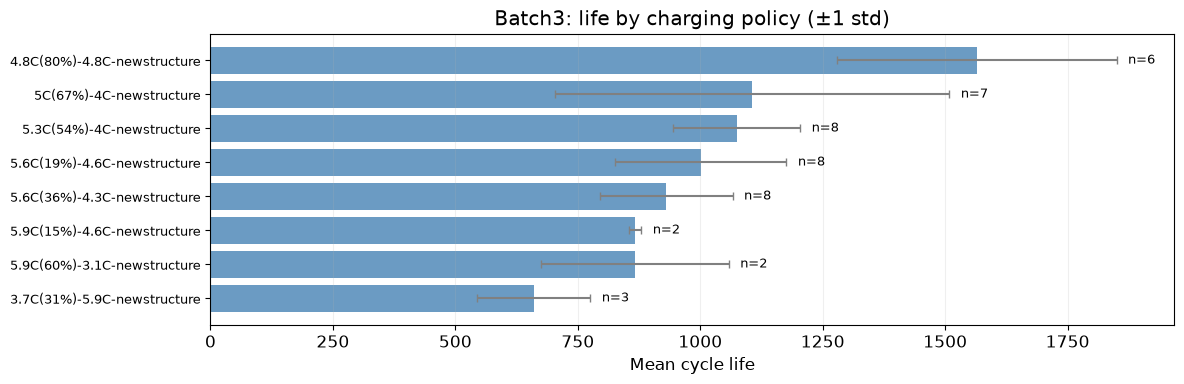

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# 수명값이 있는 셀에 충전 정책 연결
df_policy_life = df_life_valid[
    ["batch", "cell_id", "cycle_life"]
].merge(
    df_policies[["batch", "cell_id", "charging_policy"]],
    on=["batch", "cell_id"],
    how="left",
    validate="one_to_one",
)

# 정책별 수명 요약
df_policy_summary = (
    df_policy_life.groupby(["batch", "charging_policy"])
    .agg(
        n=("cell_id", "size"),
        mean_life=("cycle_life", "mean"),
        std_life=("cycle_life", "std"),
    )
    .reset_index()
)

# 정책 이름이 잘 보이도록 배치별 가로 막대그래프
for batch_name in ["Batch1", "Batch2", "Batch3"]:
    table = (
        df_policy_summary.loc[
            df_policy_summary["batch"] == batch_name
        ]
        .sort_values("mean_life")
        .reset_index(drop=True)
    )

    y = np.arange(len(table))
    error = table["std_life"].fillna(0)
    offset = table["mean_life"].max() * 0.015

    fig, ax = plt.subplots(
        figsize=(12, max(4, len(table) * 0.35))
    )

    ax.barh(
        y,
        table["mean_life"],
        xerr=error,
        color="steelblue",
        alpha=0.8,
        capsize=3,
        error_kw={"ecolor": "gray"},
    )

    # 정책별 셀 수 표시
    for i, row in table.iterrows():
        ax.text(
            row["mean_life"] + error.iloc[i] + offset,
            i,
            f"n={int(row['n'])}",
            va="center",
            fontsize=9,
        )

    ax.set_yticks(y)
    ax.set_yticklabels(table["charging_policy"], fontsize=9)
    ax.set_xlim(
        0,
        (table["mean_life"] + error).max() + offset * 5,
    )
    ax.set_xlabel("Mean cycle life")
    ax.set_title(f"{batch_name}: life by charging policy (±1 std)")
    ax.grid(axis="x", alpha=0.2)

    plt.tight_layout()
    plt.show()

| 배치 | 눈에 띄는 결과 | 해석 |
|---|---|---|
| **Batch1** | `8C(15%)-3.6C`는 약 1000사이클, `8C(35%)-3.6C`는 약 600사이클 | 같은 8C라도 **얼마나 높은 SOC까지 유지하는지**에 따라 차이. |
| **Batch2** | 같은 전류·전환 SOC 표기에서도 `newstructure` 집단의 수명이 훨씬 김 | **충전 정책 외의 실험 집단 차이**도 함께 고려. |
| **Batch3** | `4.8C(80%)-4.8C`가 가장 길고, `3.7C(31%)-5.9C`가 가장 짧음 | 첫 단계 전류가 낮아도 오래가는 건 아니야. **두 번째 단계 전류까지 함께 봐야함.** |


충전 정책을 첫 단계 C-rate·전환 SOC·두 번째 단계 C-rate로 나누어 특징 후보로 사용.

정책별 편차가 있으므로 ΔQ·온도 같은 셀의 실제 반응 정보도 함께 활용.

newstructure는 우선 실험 집단을 구분하는 정보로 유지.

결론은 “얼마나 빠르게 충전하는가”뿐 아니라, “그 속도를 어디까지 유지하고 이후 어떤 속도로 바꾸는가”도 중요\


In [4]:
# 초기·후기 기울기: 각 구간에서 7점 이동 중앙값 후 직선의 기울기 계산.
# 후기 값은 EDA에만 사용하며 수명 예측 입력에 넣지 않는다.
degradation_rows = []
for (batch_name, cell_id), curve in df_qd_valid.groupby(["batch", "cell_id"]):
    curve = curve.loc[curve.QD.gt(0)].dropna(subset=["cycle", "QD"]).sort_values("cycle")
    row = {"batch": batch_name, "cell_id": cell_id}
    for name, window in [("early", curve.loc[curve.cycle.between(10, 100)]),
                         ("late", curve.loc[curve.cycle.gt(curve.cycle.max() - 100)])]:
        smooth = window.QD.rolling(7, center=True, min_periods=1).median()
        row[name + "_drop_per100"] = (-100 * np.polyfit(window.cycle, smooth, 1)[0]
                                      if len(window) >= 3 else np.nan)
    degradation_rows.append(row)
df_degradation = pd.DataFrame(degradation_rows)

import pandas as pd

# 충전 정책에서 C1, 전환 SOC, C2 추출
pattern = (
    r"(?P<C1>\d+(?:\.\d+)?)C"
    r"\((?P<switch_SOC>\d+(?:\.\d+)?)%\)"
    r"\s*[-–]\s*"
    r"(?P<C2>\d+(?:\.\d+)?)C"
)

policy_numbers = (
    df_policy_life["charging_policy"]
    .str.extract(pattern)
    .astype(float)
)

df_charge_pattern = pd.concat(
    [
        df_policy_life.reset_index(drop=True),
        policy_numbers.reset_index(drop=True),
    ],
    axis=1,
)

# 앞서 계산한 초기·후기 감소 속도 연결
df_charge_pattern = df_charge_pattern.merge(
    df_degradation[
        [
            "batch",
            "cell_id",
            "early_drop_per100",
            "late_drop_per100",
        ]
    ],
    on=["batch", "cell_id"],
    how="left",
    validate="one_to_one",
)

inputs = ["C1", "switch_SOC", "C2"]
outcomes = [
    "cycle_life",
    "early_drop_per100",
    "late_drop_per100",
]

for batch_name in ["Batch1", "Batch2", "Batch3"]:
    group = df_charge_pattern.loc[
        df_charge_pattern["batch"] == batch_name
    ]

    corr = (
        group[inputs + outcomes]
        .corr()
        .loc[inputs, outcomes]
    )

    print(f"\n{batch_name}: 충전 조건과 수명·감소 속도의 상관")
    display(corr.round(3))


Batch1: 충전 조건과 수명·감소 속도의 상관


,cycle_life,early_drop_per100,late_drop_per100
C1,-0.580,0.135,0.608
switch_SOC,0.235,0.167,-0.339
C2,-0.096,0.527,0.021



Batch2: 충전 조건과 수명·감소 속도의 상관


,cycle_life,early_drop_per100,late_drop_per100
C1,0.191,-0.121,0.113
switch_SOC,0.116,-0.071,0.071
C2,-0.116,0.339,-0.265



Batch3: 충전 조건과 수명·감소 속도의 상관


,cycle_life,early_drop_per100,late_drop_per100
C1,-0.083,-0.715,0.478
switch_SOC,0.541,-0.271,-0.103
C2,-0.043,0.708,-0.585


- Batch1: 첫 단계 전류 C1이 클수록 수명이 짧고(−0.580), 후기 감소도 빠른 경향(+0.608)이 보임. 이 배치에서는 고속 충전 부담이라는 예상과 맞다.
- 세 배치 공통: 두 번째 단계 전류 C2가 클수록 초기 용량 감소 속도가 큰 경향이 보여(+0.527 / +0.339 / +0.708). 하지만 수명과의 직접적인 상관은 모두 약함.
- Batch3: 전환 SOC가 높을수록 수명이 긴 경향(+0.541)이 있다. 다만 전환 SOC와 함께 C1·C2도 달라지므로, 전환을 늦추면 무조건 오래간다고 해석하면 안됨.

특히 전환은 전류를 낮추는 전환일 수도, 높이는 전환일 수도 있어. 그래서 SOC 숫자 하나의 의미가 모든 정책에서 같지는 않다.

모델링 결론: 충전 조건 C1·전환 SOC·C2는 함께 고려할 보조 특징 후보로 두고, 셀이 실제로 어떻게 변했는지를 나타내는 로그 ΔQ 분산을 중심 특징으로 사용하면 됨. 충전 조건만으로 공통적인 수명 규칙을 만들기는 어려워 보임.

초기 특징과 수명의 Pearson 상관


,Batch1,Batch2,Batch3
log10_delta_Q_var,-0.886,-0.902,-0.702
delta_Q_min,0.882,0.819,0.692
delta_Q_mean,0.854,0.767,0.639
median_chargetime,0.744,-0.919,0.638
early_drop_per100,-0.520,0.427,-0.358
mean_Tavg,-0.482,0.425,-0.022
mean_Tmax,-0.404,0.019,-0.106
mean_IR,0.218,-0.627,0.190
mean_QD,0.193,-0.332,0.217
std_QD,-0.058,0.171,-0.356


특징 간 중복 정보 후보: |r| >= 0.85


,batch,feature1,feature2,r
0,Batch1,delta_Q_mean,delta_Q_min,0.993
1,Batch1,mean_Tavg,mean_Tmax,0.956
2,Batch1,delta_Q_min,log10_delta_Q_var,-0.947
3,Batch1,delta_Q_mean,log10_delta_Q_var,-0.926
4,Batch2,delta_Q_mean,delta_Q_min,0.979
5,Batch2,delta_Q_min,log10_delta_Q_var,-0.975
6,Batch2,median_chargetime,log10_delta_Q_var,0.947
7,Batch2,delta_Q_mean,log10_delta_Q_var,-0.943
8,Batch2,median_chargetime,delta_Q_min,-0.888
9,Batch3,delta_Q_mean,delta_Q_min,0.991


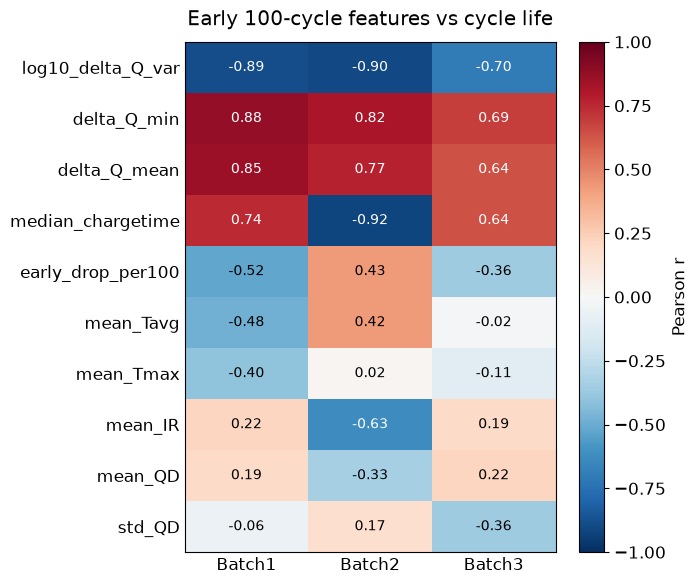

In [53]:
import pandas as pd

# 초기 100사이클의 용량 요약
qd_features = (
    df_early_valid.groupby(["batch", "cell_id"])
    .agg(
        mean_QD=("QD", "mean"),
        std_QD=("QD", "std"),
    )
    .reset_index()
)

base_cols = [
    "batch", "cell_id", "cycle_life",
    "mean_IR", "mean_Tavg", "mean_Tmax",
    "median_chargetime", "log10_delta_Q_var",
]

# 수명값이 있는 셀의 초기 특징 모으기
df_feature_review = (
    df_early_features[base_cols]
    .merge(
        qd_features,
        on=["batch", "cell_id"],
        how="left",
        validate="one_to_one",
    )
    .merge(
        df_delta_batches[
            ["batch", "cell_id", "delta_Q_mean", "delta_Q_min"]
        ],
        on=["batch", "cell_id"],
        how="left",
        validate="one_to_one",
    )
    .merge(
        df_degradation[
            ["batch", "cell_id", "early_drop_per100"]
        ],
        on=["batch", "cell_id"],
        how="left",
        validate="one_to_one",
    )
)

features = [
    "mean_QD", "std_QD", "early_drop_per100",
    "mean_IR", "mean_Tavg", "mean_Tmax",
    "median_chargetime",
    "delta_Q_mean", "delta_Q_min", "log10_delta_Q_var",
]

# 1. 수명과의 상관 — Batch1의 상관 절댓값 순서
life_corr = pd.DataFrame({
    batch_name: group[features].corrwith(group["cycle_life"])
    for batch_name, group in df_feature_review.groupby("batch")
})

order = life_corr["Batch1"].abs().sort_values(
    ascending=False
).index

print("초기 특징과 수명의 Pearson 상관")
display(life_corr.loc[order].round(3))

# 2. 특징끼리 높은 상관을 보이는 쌍
# |r| >= 0.85를 중복 정보 검토 기준으로 사용
pairs = []

for batch_name, group in df_feature_review.groupby("batch"):
    corr = group[features].corr()

    for i, feature1 in enumerate(features):
        for feature2 in features[i + 1:]:
            r = corr.loc[feature1, feature2]

            if abs(r) >= 0.85:
                pairs.append({
                    "batch": batch_name,
                    "feature1": feature1,
                    "feature2": feature2,
                    "r": r,
                    "abs_r": abs(r),
                })

df_high_corr = pd.DataFrame(
    pairs,
    columns=["batch", "feature1", "feature2", "r", "abs_r"],
)

print("특징 간 중복 정보 후보: |r| >= 0.85")
display(
    df_high_corr
    .sort_values(
        ["batch", "abs_r"],
        ascending=[True, False],
    )
    .drop(columns="abs_r")
    .reset_index(drop=True)
    .round(3)
)
import matplotlib.pyplot as plt

plot_corr = life_corr.loc[
    life_corr["Batch1"].abs().sort_values(ascending=False).index,
    ["Batch1", "Batch2", "Batch3"],
]

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(
    plot_corr.to_numpy(),
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    aspect="auto",
)

ax.set_xticks(range(3), labels=plot_corr.columns)
ax.set_yticks(range(len(plot_corr)), labels=plot_corr.index)

for i in range(len(plot_corr)):
    for j in range(3):
        value = plot_corr.iloc[i, j]
        ax.text(
            j, i, f"{value:.2f}",
            ha="center", va="center",
            color="white" if abs(value) >= 0.6 else "black",
            fontsize=10,
        )

ax.set_title("Early 100-cycle features vs cycle life", pad=12)
ax.tick_params(length=0)
fig.colorbar(im, ax=ax, label="Pearson r")

plt.tight_layout()
plt.show()

| 확인한 내용 | 모델 설계에 가져갈 결론 |
|---|---|
| 로그 ΔQ 분산–수명: **−0.886 / −0.902 / −0.702** | 세 배치에서 방향이 같고 관계도 강하므로 **대표 특징으로 선택** |
| ΔQ 평균·최솟값·로그 분산 사이의 높은 상관 | 같은 계열에서 **로그 분산 하나로 시작** |
| Tavg·Tmax가 Batch1·3에서 높은 상관 | 온도는 **Tavg 하나를 우선 후보**로 사용 |
| 충전시간은 수명과 강한 관계지만 Batch2에서 방향이 반대 | **추가 특징 후보**로 두고, 실제 개선 여부를 비교 |
| IR·초기 감소 기울기도 배치별 관계가 다름 | 보조 후보로 유지 |
| QD 평균·표준편차는 수명과 상대적으로 약한 관계 | 첫 모델에서는 우선순위를 낮춤 |


ΔQ 계열은 세 배치에서 일관된 수명 관계를 보였다. 반면 충전시간·온도·IR 등의 관계는 배치에 따라 달라, 추가 특징의 효과를 모델 평가에서 확인할 필요가 있다

기본 모델: 로그 ΔQ 분산 하나로 수명 예측.

확장 모델: 로그 ΔQ 분산 + 충전시간 중앙값 + 평균 Tavg를 사용하는 Ridge.

추가 비교 후보: 초기 감소 기울기, 충전 정책의 C1·전환 SOC·C2.

지금까지의 EDA를 근거로 **초기 100사이클을 이용한 수명 회귀 예측**으로 설계

### 1. Feature Engineering

| 특징 | 선택 이유 | 사용 방향 |
|---|---|---|
| **로그 ΔQ 분산** | 세 배치에서 수명과 일관된 음의 상관 | **핵심 특징** |
| **충전시간 중앙값** | 수명과 관련이 있고, 큰 충전시간 기록의 영향을 줄임 | 추가 효과 비교 |
| **평균 Tavg** | Batch1에서 수명과 관계가 있으며 Tmax와 정보가 겹침 | 온도 대표 후보 |
| 초기 용량 감소 기울기 | 초기 열화 진행 속도를 표현 | 추가 검토 |
| C1·전환 SOC·C2 | 충전 전략을 숫자로 표현 | 추가 검토 |

ΔQ 평균·최솟값은 로그 분산과 정보가 많이 겹치므로 첫 모델에서는 제외한다. Tmax도 Tavg와 중복되어 제외한다. QD 평균·표준편차와 IR은 첫 모델에서 우선순위를 낮춘다.

**첫 비교는 로그 ΔQ 분산 하나로 시작하고, 충전시간·온도를 추가했을 때 개선되는지 확인한다.**

### 2. Regression 선택과 Target

- **선택:** Regression
- **Target:** 최종 배터리 수명인 `cycle_life`
- **예측 시점:** 100사이클 완료 시점
- **분석 단위:** 셀 1개당 1행

수명을 장·단수명으로 나누는 것보다 **몇 사이클까지 사용할 수 있는지 수치로 예측**하려는 목적에 맞는다. 이미 분석한 ΔQ100−10 특징도 활용할 수 있다.

### 3. Modeling Strategy

**데이터 처리**

- 수명 결측 셀은 제외하고, 미완료·연속 실험 셀의 최종 수명은 확인 후 사용한다.
- 초기의 모든 측정값이 0인 기록은 집계에서 제외한다.
- 충전시간은 중앙값으로 요약하고, 정상적인 후기 용량 감소는 유지한다.
- 모든 입력은 초기 100사이클까지의 정보로 구성한다.
- 결측 대체·표준화는 학습 데이터 또는 각 CV 학습 폴드 안에서 수행한다.

**후보 모델**

| 모델 | 비교 목적 |
|---|---|
| **평균 수명 예측** | 특징 없이 예측하는 기준 성능 |
| **선형 회귀 — 로그 ΔQ 분산만 사용** | 핵심 특징 하나로 얼마나 예측 가능한지 확인 |
| **Ridge — 로그 ΔQ 분산 + 충전시간 중앙값 + Tavg** | 추가 특징의 효과를 확인하고 계수의 불안정성을 완화 |

학습 셀 수가 적으므로 소수의 특징과 단순한 모델부터 비교한다. 특징은 상관계수만으로 최종 확정하지 않고 **교차검증 성능으로 선택**한다.

**분할·평가**

- Batch1을 **셀 단위**로 학습·보관 평가 데이터로 나눈다.
- 학습 부분에서 **5-fold CV**로 후보를 비교한다.
- 선택 모델을 Batch2에서 평가한다. Batch3 추가 평가는 선택 사항이며 실제 DAY2에서는 수행하지 않았다.
- 주 지표는 **MAPE**, 보조 지표는 **MAE·RMSE**로 한다.
- 배치별 수명 분포가 다르므로 **짧은 수명과 긴 수명에서 오차가 어떻게 달라지는지**도 확인한다.

Batch2·3은 이미 EDA에서 살펴봤으므로 그 사실을 기록하고, 이후 모델 선택과 튜닝은 Batch1 개발 데이터에서 진행한다.